In [2]:
import yaml
import argparse

import torch
from torch import nn
#from loss import *

import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
if not abs_path in sys.path:
    sys.path+=[abs_path, f'{abs_path}/third_party/siren']
else:
    sys.path+=[f'{abs_path}/third_party/siren']
sys.path+=[abs_path, f'{abs_path}/third_party/diffusion-net/src']
import diffusion_net
    
try:
    import modules
    from meta_modules import HyperNetwork
except:
    !pip install h5py
    import modules
    from meta_modules import HyperNetwork
    
    
%load_ext autoreload
%autoreload 2
from models.encoder import BaseDiffusionNetEncoder, HyperDiffusionNet
from models.siren_decoder import SurfaceDeformationField

config = f'{abs_path}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = False
opts.dec_type = 'disp'
# opts.ckpt = '../ckpt_stage1/2024-08-18-23-32-29-all' ## ------> load checkpoint
# opts.ckpt = '../ckpt_stage1/2024-06-09-10-57-34-all'
# opts.ckpt = '../ckpt_stage1/2024-07-08-06-27-12-all'
opts.ckpt = '../ckpts/2025-04-12-08-30-12-all'
# opts.ckpt = '../ckpts/2025-04-23-13-35-59-all'
opts.design = 'new2'

# dummy...
opts.device="cuda:0"
opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.scale_exp = 1.0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
in_shape_dict = {'cents&norms':6, 'cents':3, 'cents&norms&seg':7}
out_shape_dict = {'vert': 3, 'disp': 3, 'jacob': 9}

# me = BaseDiffusionNetEncoder(
#                 in_shape=in_shape_dict['cents&norms'],
#                 pre_computes=None,
#                 out_shape=128,
#             )

In [3]:
import pickle

with open('/data/sihun/ICT-audio2face/precompute-synth-fullhead/000_dfn_info.pkl', 'rb') as f:
    asd = pickle.load(f)
# asd
batch_mass, batch_L, batch_evals, batch_evecs, batch_grad_X, batch_grad_Y = [],[],[],[],[],[]
# for dfn_info_path in batch.dfn_info:
# dfn_info = pickle.load(open(dfn_info_path, 'rb')) # DiffusionNet info
dfn_info = asd
dfn_info = [_.cuda().float().requires_grad_(False) if type(_) is not torch.Size else _  for _ in dfn_info]

batch_mass.append(dfn_info[0])
batch_L.append(dfn_info[1])
batch_evals.append(dfn_info[2])
batch_evecs.append(dfn_info[3])
batch_grad_X.append(dfn_info[4])
batch_grad_Y.append(dfn_info[5])

batch_mass=torch.stack(batch_mass).cuda().requires_grad_(False)
batch_L=torch.stack(batch_L).cuda().requires_grad_(False)
batch_evals=torch.stack(batch_evals).cuda().requires_grad_(False)
batch_evecs=torch.stack(batch_evecs).cuda().requires_grad_(False)

In [7]:
print(batch_mass.shape)
print(batch_L.shape)
print(batch_evals.shape)
print(batch_evecs.shape)
print(batch_grad_X[0].shape)
print(batch_grad_Y[0].shape)

torch.Size([1, 11248])
torch.Size([1, 11248, 11248])
torch.Size([1, 128])
torch.Size([1, 11248, 128])
torch.Size([11248, 11248])
torch.Size([11248, 11248])


In [7]:
ID_DIM = 32
me = HyperDiffusionNet(
        C_in=in_shape_dict['cents&norms'],
        C_width=ID_DIM,
        N_block=1,
        num_hidden_layers=1,
        hyper_num_hidden_layers=1,
        C_out=128,
    ).cuda()

be = diffusion_net.DiffusionNet(
        C_in=in_shape_dict['cents&norms'],
        C_out=128,
    ).cuda()

In [4]:
ae = AdaINDiffusionNet(
        C_in=in_shape_dict['cents&norms'],
        C_width=128,
        ID_dims=128,
        N_block=4,
        C_out=128,
    ).cuda()

In [5]:
ae.update_precomputes(dfn_info)

In [6]:
# output = me(
#     id_in=torch.rand(1,11248 ,128).cuda(), 
#     x_in=torch.rand(1,11248 ,6).cuda(), 
#     mass=batch_mass, 
#     L=batch_L, 
#     evals=batch_evals, 
#     evecs=batch_evecs, 
#     gradX=batch_grad_X, 
#     gradY=batch_grad_Y
# )
output = ae(
    id_in=torch.rand(1,11248 ,128).cuda(), 
    x_in=torch.rand(1,11248 ,6).cuda(), 
    # mass=batch_mass, 
    # L=batch_L, 
    # evals=batch_evals, 
    # evecs=batch_evecs, 
    # gradX=batch_grad_X, 
    # gradY=batch_grad_Y
)

TypeError: AdaINDiffusionNet.forward() missing 1 required positional argument: 'mass'

In [10]:
output.shape

torch.Size([1, 11248, 128])

In [4]:
se = SurfaceDeformationField(                        
        in_dim=in_shape_dict['cents&norms'],
        out_shape=128,
    ).cuda()
# print(me.blocks[0].hyper_net.names)
# print(me.blocks[0].hyper_net)

In [15]:
torch.cuda.empty_cache()

In [1]:
# # se
# output = se(
#     id_input=torch.rand(1,11248 ,128).cuda(), 
#     vtx_input=torch.rand(1,11248 ,6).cuda(), 
# )

# # output = se(
# #     id_input=torch.rand(1,2048,128).cuda(),
# #     vtx_input=torch.rand(1,2048,6).cuda(),
# # )

# retarget experiment

In [5]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']

%load_ext autoreload
%autoreload 2
from evaluation import Options, Trainer

import trimesh
from utils import ICT_face_model
from utils.matplotlib_rnd import (
    render_mesh_diff,
    render_wo_audio,
    plot_image_array,
    plot_image_array_seg
)
biwi_align_mat = np.load(f'{abs_path}/utils/biwi/align.npy')
voca_align_mat = np.load(f'{abs_path}/utils/voca/align.npy')
# voca_std = np.load('./utils/voca/standardization.npy', allow_pickle=True).item()

def mesh_alignment(vertices, mean=None, mesh_data="voca", return_mean=False):
    if mesh_data == "biwi":
        mat = biwi_align_mat

        if mean is None:
            mean = vertices.mean(0)
        vertices = vertices - mean
    elif mesh_data == "voca":
        mat = voca_align_mat

    vertices = np.c_[vertices, np.ones([*vertices.shape[:-1], 1])]
    vertices = vertices @ mat.T
    vertices = vertices[..., :3]
    if return_mean:
        return vertices, mean
    return vertices


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pickle

%load_ext autoreload
%autoreload 2
from utils.matplotlib_rnd import (
    render_mesh_diff,
    render_wo_audio,
    plot_image_array,
    plot_image_array_seg,
    plot_image_array_col,
    plot_image_array_grd,
    plot_image_array_diff,
    plot_image_array_diff2,
    plot_image_array_diff3,
    plot_image_array_diff4
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
config = f'{abs_path}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = False
opts.dec_type = 'disp'
# opts.ckpt = '../ckpt_stage1/2024-08-18-23-32-29-all' ## ------> load checkpoint
# opts.ckpt = '../ckpt_stage1/2024-06-09-10-57-34-all'
# opts.ckpt = '../ckpt_stage1/2024-07-08-06-27-12-all'
opts.ckpt = '../ckpts/2025-04-12-08-30-12-all'
# opts.ckpt = '../ckpts/2025-04-23-13-35-59-all'
opts.design = 'new2'

# dummy...
opts.device="cuda:0"
opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.scale_exp = 1.0

# trainer = Trainer(opts, num=1800)
# trainer = Trainer(opts, num=1900)
trainer = Trainer(opts)
# trainer = Trainer(opts, num=400)

In [8]:

%load_ext autoreload
%autoreload 2
from models import NFS

config = f'{abs_path}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = False
opts.dec_type = 'jacob'
opts.ckpt = ''
opts.design = 'new2'

# dummy...
opts.device="cuda:0"
opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.scale_exp = 1.0

nfs = NFS(opts, None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[DiffusionNet] warning: no pre_computes provided!
[DiffusionNet] warning: no pre_computes provided!
[DiffusionNet] warning: no pre_computes provided!
===========< NFS >===========
[mesh_decoder]: 	602377
[mesh_id_encoder]: 	1906560
[mesh_exp_encoder]: 	1906560
[mesh_seg_encoder]: 	1878804
-------------------------------
[total]: 	6832733


torch.Size([11248, 20])


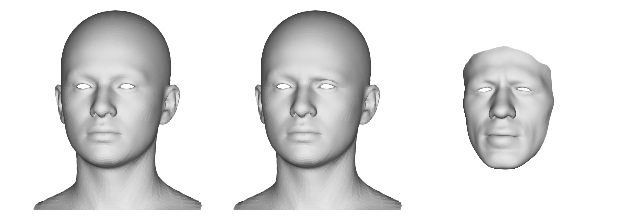

In [7]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

############################################
## flame
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/FLAME_sample.ply', process=False, maintain_order=True)
# flame_tri.vertices = mesh_alignment(flame_tri.vertices, mean=None, mesh_data="voca", return_mean=False)
# _=flame_tri.export(f'{abs_path}/test-mesh/FLAME_sample_align.obj')

# flame_tri = trimesh.load(f'{abs_path}/test-mesh/FaceTalk_170725_00137_TA.ply', process=False, maintain_order=True)
# #with open("/data/sihun/VOCA-COMA/raw_templates.pkl", "rb") as f:
#     # voca_pkl = pickle.load(f, encoding="latin")
# #     flame_tri.vertices=voca_pkl['FaceTalk_170809_00138_TA'] # MALE
# #     flame_tri.vertices=voca_pkl['FaceTalk_170731_00024_TA'] # FEMALE
#     #flame_tri.vertices = mesh_alignment(flame_tri.vertices, mean=None, mesh_data="voca", return_mean=False)
#     #flame_tri.vertices = flame_tri.vertices + np.array([[0, -0.15, 0]])

# flame_tri = trimesh.load(f'{abs_path}/test-mesh/FaceTalk_170725_00137_TA.ply', process=False, maintain_order=True)
# with open("/data/sihun/VOCA-COMA/voca_templates.pkl", "rb") as f:    
#     voca_pkl = pickle.load(f, encoding="latin")
#     voca_coma_std = np.load('../utils/voca/standardization.npy', allow_pickle=True).item()
# #     flame_tri.vertices=voca_pkl['FaceTalk_170809_00138_TA'] # MALE
#     flame_tri.vertices=voca_pkl['FaceTalk_170731_00024_TA'] # FEMALE
#     flame_tri.faces=voca_coma_std["new_f"]
############################################
    
############################################
flame_tri = trimesh.load(f'{abs_path}/test-mesh/BIWI.ply', process=False, maintain_order=True)
with open(f'{abs_path}/test-mesh/biwi_templates.pkl',"rb") as f:
    asd = pickle.load(f)
    #print(asd.keys())
flame_tri.vertices = asd['M5']
flame_tri.vertices = mesh_alignment(flame_tri.vertices, mean=None, mesh_data="biwi", return_mean=False)

# _=flame_tri.export('biwi_M5.obj')
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/biwi_F1.obj', process=False, maintain_order=True)
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/face-reference.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices*0.11 + np.array([[0, -0.15, -0.25]])
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/head-reference.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices*0.11 + np.array([[0, -0.27, 0]])
############################################


############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/meshtalk_20180426_cut.obj', process=False, maintain_order=True)
############################################

############################################
# # flame_tri = trimesh.load(f'{abs_path}/test-mesh/malchom-align.obj', process=False, maintain_order=True)
# # flame_tri.vertices = flame_tri.vertices*.95 + np.array([[0, 0.05, 0.0]])
# # _=flame_tri.export('malcolm-align.obj')
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/malcolm-align.obj', process=False, maintain_order=True)
############################################

############################################
# flame_tri = trimesh.load('/data/sihun/multiface_align/obj/m--20180226--0000--6674443--GHS_mesh.obj', process=False, maintain_order=True) # train
# flame_tri = trimesh.load('/data/sihun/multiface_align/obj/m--20190529--1300--002421669--GHS_mesh.obj', process=False, maintain_order=True) # valid
# flame_tri = trimesh.load('/data/sihun/multiface_align/obj/m--20190828--1318--002645310--GHS_mesh.obj', process=False, maintain_order=True) # test
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/ict_live_100_000.obj', process=False, maintain_order=True)
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/mary-align.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices + np.array([[0, -0.05, -0.35]])
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/piers-align.obj', process=False, maintain_order=True)
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/bonnie-bald-align.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices*1.1 + np.array([[0, 0.1, 0.25]])
############################################

############################################
# flame_tri = trimesh.load(f'{abs_path}/test-mesh/morphy-align.obj', process=False, maintain_order=True)
############################################

# flame_tri = trimesh.load('/data/sihun/arkit_CSH/arkit_frame_001189.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices *0.1
# flame_tri.vertices = flame_tri.vertices[:ict_tri.vertices.shape[0]]
# flame_tri.faces = ict_tri.faces


ict_vert_segment = torch.from_numpy(np.load('../utils/ict/ICT_segment_onehot.npy'))
print(ict_vert_segment.shape)
## ICT random expression
BS_N = 26
# BS_N = 49
# BS_N = 4

BS_N = 45
BS_N = 0
bs_coeff = np.eye(53)[BS_N]
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))

#######################################################
src_mesh = ict_tri
tgt_mesh = flame_tri
#######################################################

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, 
    bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

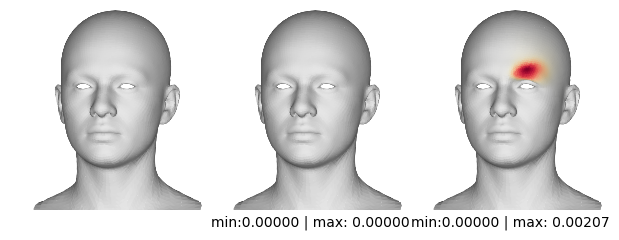

In [30]:

M_SCALE = 0.68

v_list=[ ict_tri.vertices * M_SCALE, vertices[0].numpy() * M_SCALE] 
f_list=[ ict_tri.faces, ict_tri.faces]
d_list=[ ict_tri.vertices * M_SCALE ] # 기준!
SIZE=2

plot_image_array_diff2(
    v_list, f_list, d_list[0],
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, 
    bg_black=False, 
)

In [33]:
# # gt_frames = torch.load("/source/sihun/NFS/notebook/gt_frames.pth")
# # print(gt_frames.shape)

# # import pickle
# # NAME="arkit_CSH_shade-gt_frames"
# # with open(f"tmp/arkit/{NAME}.pkl", "wb") as f:
# #     asd = {"pred_outs":gt_frames,"pred_seg":ict_vert_segment}
# #     pickle.dump(asd, f)
# _=ict_tri.export("/source/sihun/NFS/test-mesh/ict_neutral_rescale.obj")

In [119]:
from tqdm import tqdm

In [6]:
select = np.random.randint(0,1200,(100))

In [7]:
select

array([1126,  860, 1130, 1095, 1044,  121,  466,  330,   87, 1123,  871,
        130,  769,  343,  805,  385,  955,  276, 1184,  459,   21,  252,
        747,  856,  474, 1082,  510,  699,  975,  189,  957,  686,  957,
        562,  831, 1154,  646,   20,  840,  166,  387,  600,  315,   13,
        241,  776,  564,  897,   91,  955,  508,  775,   34,  205, 1104,
       1025, 1021,  565, 1129,  702,  401,  729,  161,  201,  995,  269,
        815,  455, 1016,  295,  719,  337,  878, 1076,  791,  216,  763,
        187,  379,  492, 1064, 1180,   14,   64,  520, 1152,  647, 1086,
       1162,  592,  391,  418,  288,  378,  230, 1017,   40, 1051,  134,
        200])

In [8]:
bs_coeff = np.random.randn(100)

  0%|          | 0/1 [00:00<?, ?it/s]

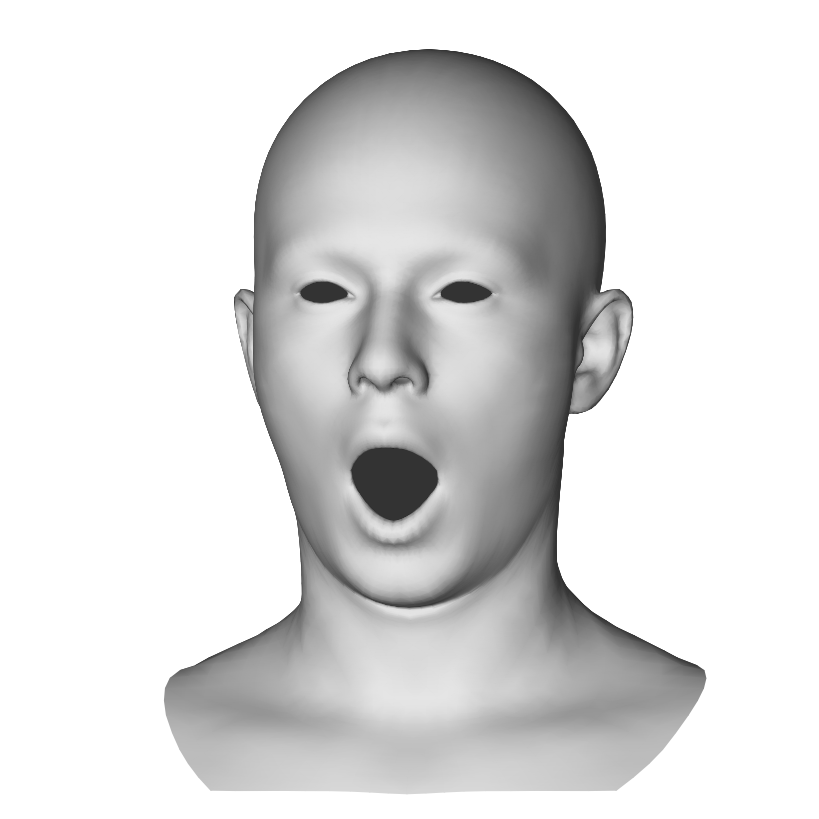

  0%|          | 0/1 [00:00<?, ?it/s]


In [135]:
SIZE=8
# M_SCALE = 1.5
M_SCALE = .55

SEG_N = 3
# SEG_N = 8
# SEG_N = 10

BS_N = 26
# BS_N = 49
# BS_N = 4

# BS_N = 45
# for BS_N in [26, 49, 4]:
#     bs_coeff = np.eye(53)[BS_N]
#     vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
#     v_list=[ vertices[0] * M_SCALE + np.array((-.3,-0.5,0)) ]
#     v_list=[ v *M_SCALE for v in v_list]
#     f_list=[ ict_tri.faces ]
#     c_list=[ ict_vert_segment ]

#     plot_image_array_grd(
#         v_list, f_list, c_list, 
# #         seg_only=SEG_N,
#         blend=0.5,
#         rot_list=[[0,-10,0]]*len(v_list), 
#         size=SIZE, bg_black=False, mode='shade', 
#         logdir=f"tmp/ppt", 
#         name=f"BS-{BS_N:03d}-seg-{SEG_N:02d}",
#         save=False
#     )
#     break

#vertices = torch.from_numpy(ict_tri.vertices)
# vertices = flame_tri.vertices[None]
# faces = flame_tri.faces
vertices = ict_tri.vertices
faces = ict_tri.faces



# # with open('/source/sihun/NFS/notebook/tmp/arkit/arkit_CSH_shade-FLAME_test_F.pkl', 'rb') as f:
# with open('/source/sihun/NFS/notebook/tmp/arkit/arkit_CSH_shade-gt_frames.pkl', 'rb') as f:
# # with open('/source/sihun/NFS/notebook/tmp/arkit/arkit_CSH_shade-MF_test.pkl', 'rb') as f:
# # with open('/source/sihun/NFS/notebook/tmp/arkit/arkit_CSH_shade-morphy_test.pkl', 'rb') as f:
#     # {"pred_outs":pred_outs,"pred_seg":pred_seg}
#     pkl_file = pickle.load(f)
    
# #vertices = pkl_file['pred_outs']
# vertex_frames = pkl_file['pred_outs'].detach().cpu().numpy()
# vertex_frames = vertex_frames[select]

# vertex_frames = vertex_frames + ict_face_model.get_id_disp(bs_coeff)
# BS_N = 45
bs_coeff = np.eye(53)[BS_N]
vertex_frames = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
vertex_frames = vertex_frames.numpy()

# logdir=f"tmp/ppt/arkit_CSH_shade-gt_frames-few"


logdir=f"tmp/ppt/"
os.makedirs(logdir, exist_ok=True)
    
for idx, vertices in tqdm(enumerate(vertex_frames), total=len(vertex_frames)):
    v_list=[ vertices * M_SCALE]
#     v_list=[ vertices * 0.45]
#     v_list=[ v for v in v_list]

    v_list=[ v+np.array([0,0.1,0]) for v in v_list]

    f_list=[ faces ]
    c_list=[ ict_vert_segment ]
    diff_list=[ vertices - ict_tri.vertices ]
    plot_image_array_grd(
        v_list, f_list, 
#         c_list, 
#         diff_list, is_diff=True, diff_base=ict_tri.vertices,
        # seg_only=SEG_N,
        #blend=0.5,
        blend=0,
        rot_list=[[0,-10,0]]*len(v_list), 
        size=SIZE, bg_black=False, mode='shade', 
        logdir=logdir, 
        #seg_divide=True,
        name=f"BS-ICT-{idx:04d}",
#         show=False,
        show=True,
        save=True
    )
    break
# ffmpeg -i images-%04d.png -c:v libx264 -pix_fmt yuv420p -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2:color=white" -r 12 -y -an arkit_CSH_shade-gt_frames-few.mp4

In [ ]:
# from IPython.display import Video
# Video("tmp/ppt/arkit_CSH_shade-gt_frames-few/out.mp4")

# ffmpeg -i "arkit_CSH_shade-gt_frames-few/arkit_CSH_shade-gt_frames-few.mp4" \
# -i "arkit_CSH_shade-gt_frames-few-2/arkit_CSH_shade-gt_frames-few-2.mp4" \
# -i "arkit_CSH_shade-gt_frames-few-3/arkit_CSH_shade-gt_frames-few-3.mp4" \
# -filter_complex "[0:v][1:v][2:v]hstack=inputs=3[v]" -map "[v]" "output.mp4"


In [196]:
pred_outputs, pred_seg = trainer.model.inference(
    gt_vertices=vertices, 
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh, #tgt_mesh,
    return_seg=True,
)

decoding...: 100%|██████████| 1/1 [00:00<00:00, 404.70it/s]


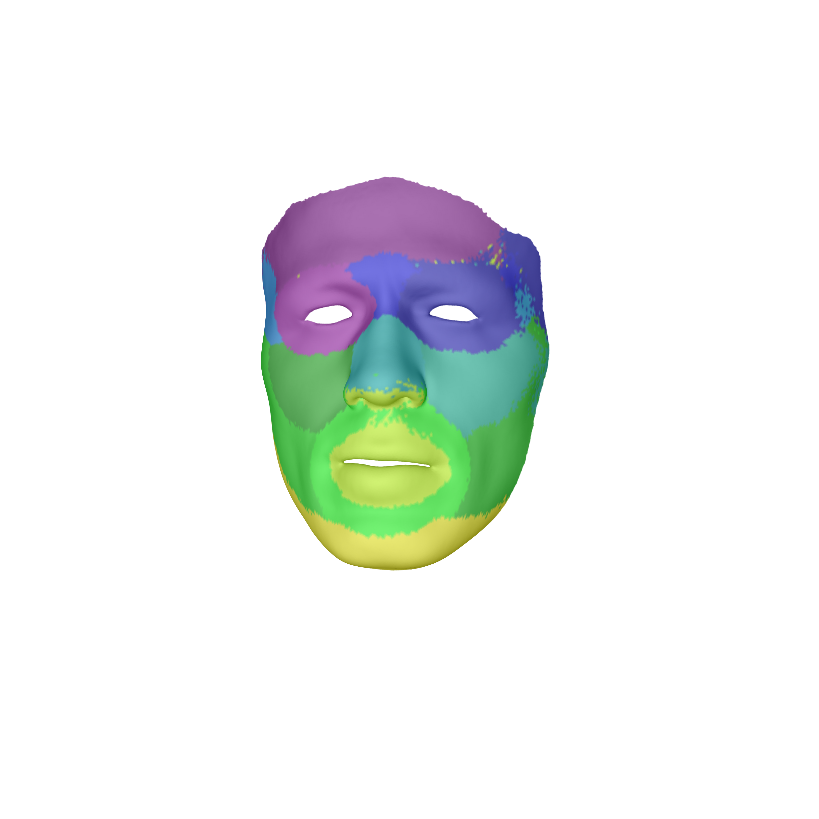

In [197]:
SIZE=8
M_SCALE=.55

M_trans=np.array([0,0.07,0])
v_list=[ pred_outputs.detach().cpu().numpy()[0] ]
# v_list=[ pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
# v_list=[ flame_tri.vertices]
# v_list=[ v+np.array([0,0.07,0]) for v in v_list]
#f_list=[ flame_tri.faces ]
f_list=[ tgt_mesh.faces ]
c_list=[ pred_seg.detach().cpu()[0] ]

plot_image_array_grd(
    v_list, f_list, 
    c_list, 
    # is_diff=True, diff_base=flame_tri.vertices,
    # seg_only=10,
    rot_list=[[0,-10,0]]*len(v_list), 
    mesh_scale=M_SCALE,
    mesh_trans=M_trans,
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"tmp/ppt", 
    name=f"BIWI_M5-segment", 
    save=True
)

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


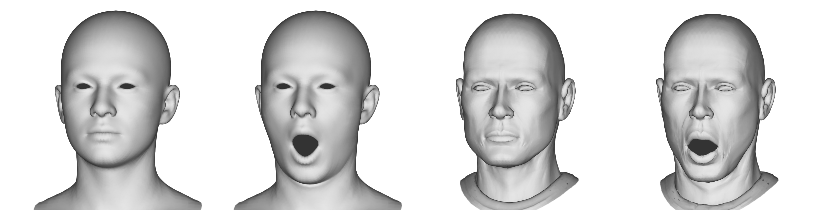

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


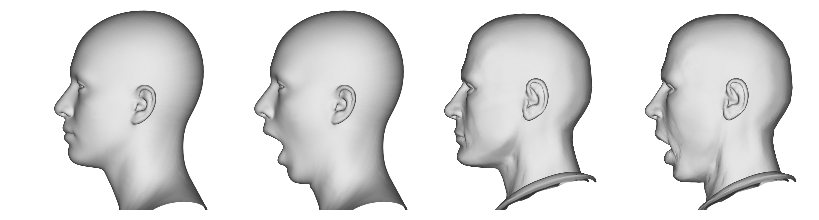

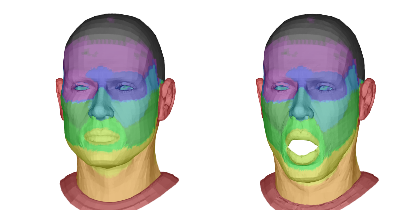

In [505]:
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array_grd(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"tmp/ppt", 
    name=f"test", save=False
)
print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
# plot_image_array(
plot_image_array_grd(
    v_list, f_list,
    rot_list=[[0,-90,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"tmp/ppt", 
    name=f"test", save=False
)

v_list=[ flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ flame_tri.faces, flame_tri.faces ]

c_list=[pred_seg.detach().cpu()[0], pred_seg.detach().cpu()[0]]
plot_image_array_seg(
    v_list, f_list, c_list, 
    rot_list=[[0,-10,0]] * 2, 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [228]:
# pred_seg1 = pred_seg
# pred_sw1 = trainer.model.get_mesh_skinning_weight(pred_seg1)
# tgt_mesh1 = tgt_mesh

# pred_seg2 = pred_seg
# pred_sw2 = trainer.model.get_mesh_skinning_weight(pred_seg2)
# tgt_mesh2 = tgt_mesh

# pred_seg3 = pred_seg
# pred_sw3 = trainer.model.get_mesh_skinning_weight(pred_seg3)
# tgt_mesh3 = tgt_mesh

# pred_seg4 = pred_seg
# pred_sw4 = trainer.model.get_mesh_skinning_weight(pred_seg)
# tgt_mesh4 = tgt_mesh

pred_seg5 = pred_seg
pred_sw5 = trainer.model.get_mesh_skinning_weight(pred_seg)
tgt_mesh5 = tgt_mesh

In [88]:
# pred_sw1 = pred_sw

In [95]:
def generate_colors(n):
    hues = [i / n for i in range(n)]
    saturation = 1
    value = 1
    colors = [colorsys.hsv_to_rgb(hue, saturation, value) for hue in hues]
    colors = [(int(r * 255), int(g * 255), int(b * 255)) for r, g, b in colors]
    return colors

def plot_mesh(myMesh,cmap=None):
    mp.plot(myMesh.vert, myMesh.face,c=cmap)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vert, myMesh1.face, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vert, myMesh2.face, c=cmap2, s=[2, 2, 1], data=d)

def get_colors(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

def cosine_similarity(a, b):
    if len(a) > 30000:
        return cosine_similarity_batch(a, b, batch_size=30000)
    dot_product = torch.mm(a, b.t())
    norm_a = torch.norm(a, dim=1, keepdim=True)
    norm_b = torch.norm(b, dim=1, keepdim=True)
    similarity = dot_product / (norm_a * norm_b.t())

    return similarity


def cosine_similarity_batch(a, b, batch_size=30000):
    num_a, dim_a = a.size()
    num_b, dim_b = b.size()
    similarity_matrix = torch.empty(num_a, num_b, device="cpu")
    for i in tqdm(range(0, num_a, batch_size)):
        a_batch = a[i:i+batch_size]
        for j in range(0, num_b, batch_size):
            b_batch = b[j:j+batch_size]
            dot_product = torch.mm(a_batch, b_batch.t())
            norm_a = torch.norm(a_batch, dim=1, keepdim=True)
            norm_b = torch.norm(b_batch, dim=1, keepdim=True)
            similarity_batch = dot_product / (norm_a * norm_b.t())
            similarity_matrix[i:i+batch_size, j:j+batch_size] = similarity_batch.cpu()
    return similarity_matrix

In [240]:
def get_cs_index(src_seg, tgt_seg):
    s = cosine_similarity(src_seg, tgt_seg)
    s = torch.argmax(s, dim=0).cpu().numpy()
    return s

In [239]:
pred_sw1.shape

torch.Size([1, 3694, 128])

In [742]:
device='cuda:0'
# s = cosine_similarity(pred_sw1[0].to(device), pred_sw2[0].to(device))
# s = cosine_similarity(pred_seg1[0].to(device), pred_seg2[0].to(device))
# s = cosine_similarity(pred_seg1[0].to(device), pred_seg3[0].to(device))
# s = cosine_similarity(pred_seg1[0].to(device), pred_seg4[0].to(device))
# s = cosine_similarity(pred_seg1[0].to(device), pred_seg5[0].to(device))
# s = torch.argmax(s, dim=0).cpu().numpy()
cmap_source = get_colors(tgt_mesh1.vertices)
s2 = get_cs_index(pred_seg1[0].to(device), pred_seg2[0].to(device))
s3 = get_cs_index(pred_seg1[0].to(device), pred_seg3[0].to(device))
s4 = get_cs_index(pred_seg1[0].to(device), pred_seg4[0].to(device))
s5 = get_cs_index(pred_seg1[0].to(device), pred_seg5[0].to(device))

# s2 = get_cs_index(pred_sw1[0].to(device), pred_sw2[0].to(device))
# s3 = get_cs_index(pred_sw1[0].to(device), pred_sw3[0].to(device))
# s4 = get_cs_index(pred_sw1[0].to(device), pred_sw4[0].to(device))
# s5 = get_cs_index(pred_sw1[0].to(device), pred_sw5[0].to(device))

cmap_target2 = cmap_source[s2]
cmap_target3 = cmap_source[s3]
cmap_target4 = cmap_source[s4]
cmap_target5 = cmap_source[s5]

In [260]:
def softmax(x):
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(-1)[...,None]

In [269]:
pred_sw1.max()

tensor(370.0237, device='cuda:0', grad_fn=<MaxBackward1>)

(3694, 128) (128,) (128,) [0.9999999 1.0000001 1.0000001 ... 1.        1.0000001 0.9999998] (3694,)


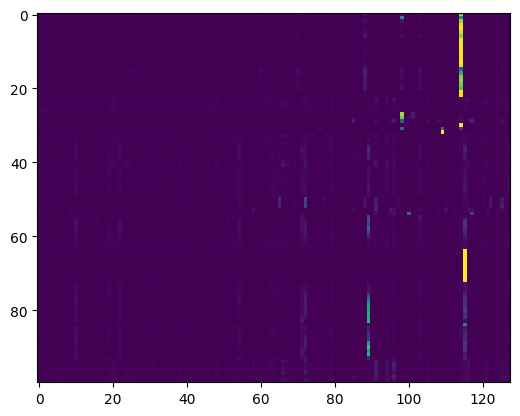

In [326]:
import matplotlib.pyplot as plt
# plt.imshow(cmap_source[None].repeat(500,0))
# psw1 = pred_sw1.detach().cpu().numpy()[0]
psw1 = torch.nn.functional.softmax(pred_sw1[0], dim=1).detach().cpu().numpy()
print(psw1.shape, psw1.min(0).shape, psw1.max(0).shape, psw1.sum(1), psw1.sum(1).shape)
plt.imshow(psw1[1100:1200])

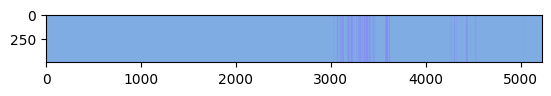

In [243]:
plt.imshow(cmap_target2[None].repeat(500,0))

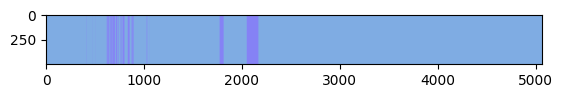

In [244]:
plt.imshow(cmap_target3[None].repeat(500,0))

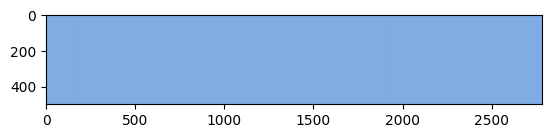

In [245]:
plt.imshow(cmap_target4[None].repeat(500,0))

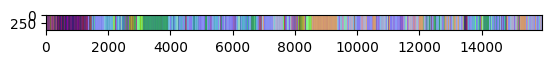

In [230]:
plt.imshow(cmap_target5[None].repeat(500,0))

In [744]:
M_SCALE=0.53
SIZE=6

v_list=[ tgt_mesh1.vertices, tgt_mesh2.vertices, tgt_mesh3.vertices, tgt_mesh4.vertices, tgt_mesh5.vertices ]
v_list=[ v*M_SCALE for v in v_list ]
f_list=[ tgt_mesh1.faces, tgt_mesh2.faces, tgt_mesh3.faces, tgt_mesh4.faces, tgt_mesh5.faces ]
c_list=[cmap_source, cmap_target2, cmap_target3, cmap_target4, cmap_target5]

plot_image_array_col(
    v_list, f_list, c_list, 
    rot_list=[[0,0,0]] * len(v_list), 
    size=SIZE, bg_black=False, mode='shade',
    logdir=f"tmp", 
    name=f"test-skin", save=False, blend=0.5
)

In [347]:
print(pred_sw5.shape)
pred_sw5_bs = pred_sw5[...,:53].detach().cpu()
print(pred_sw5_bs.shape)
pred_sw5_sm = torch.nn.functional.softmax(pred_sw5_bs, dim=-1)
print(pred_sw5_sm.sum(-1).shape, pred_sw5_sm.sum(-1))
BS_N = 10
pred_sw5_1 = pred_sw5_sm[...,BS_N] * 100
pred_sw5_1 = pred_sw5_1.type(torch.long)
print(pred_sw5_1.min(), pred_sw5_1.max())
pred_sw5_1 = torch.eye(100)[pred_sw5_1]
print(pred_sw5_1.shape)

torch.Size([1, 15941, 128])
torch.Size([1, 15941, 53])
torch.Size([1, 15941]) tensor([[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]])
tensor(0) tensor(28)
torch.Size([1, 15941, 100])


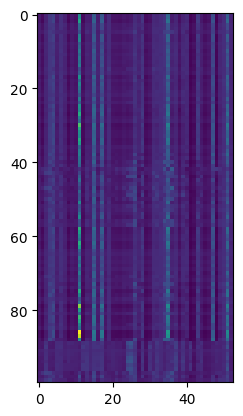

In [399]:
# pred_sw5_sm.shape
plt.imshow(pred_sw5_sm[0,1100:1200])
# pred_sw5.shape

0


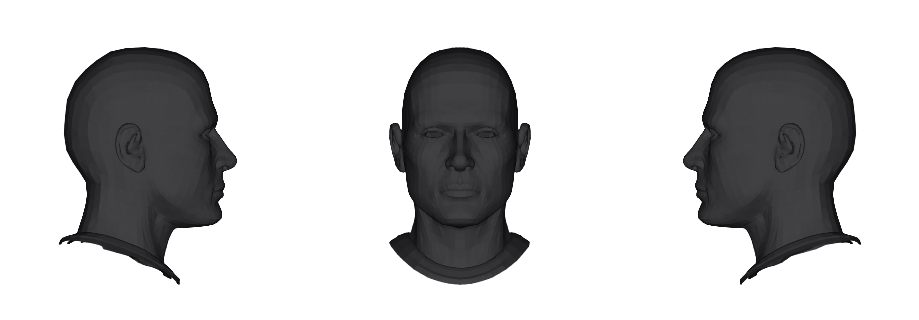

1


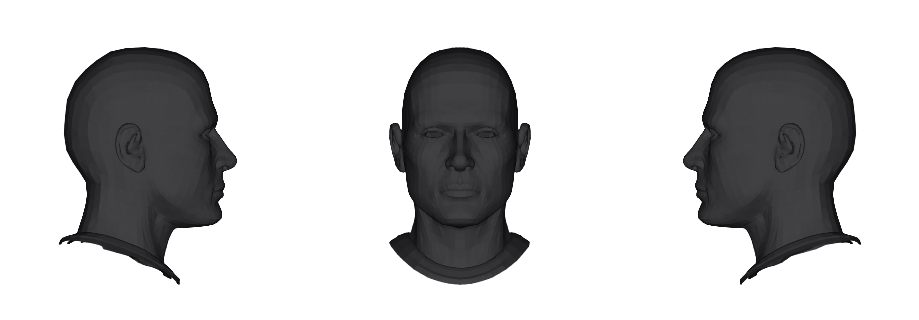

2


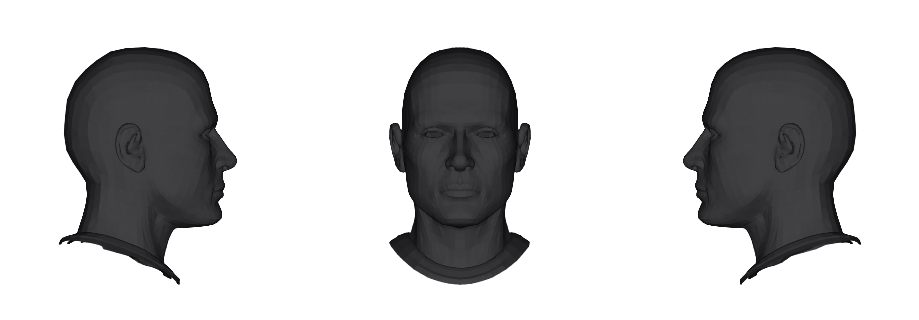

3


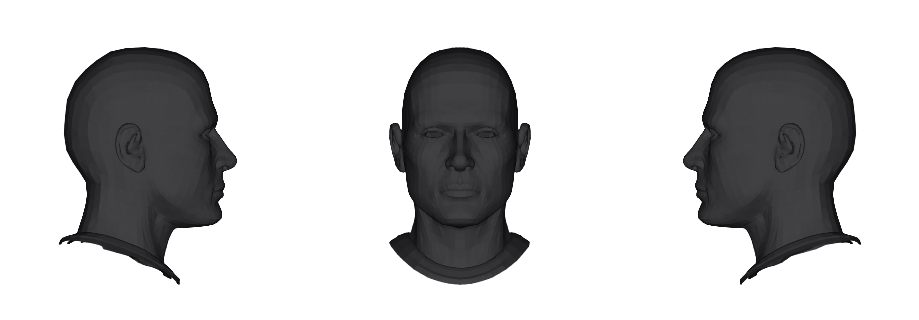

4


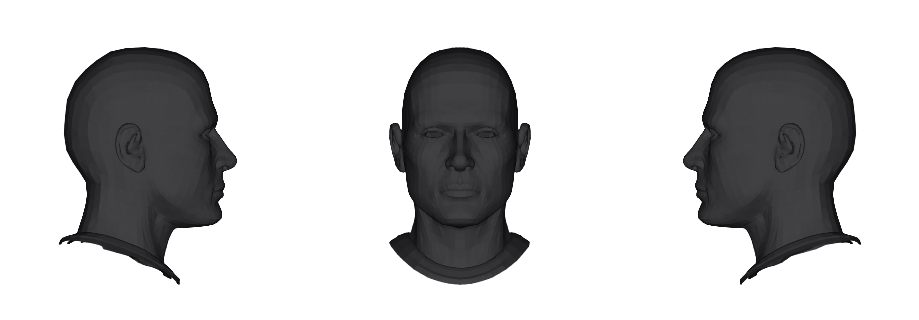

5


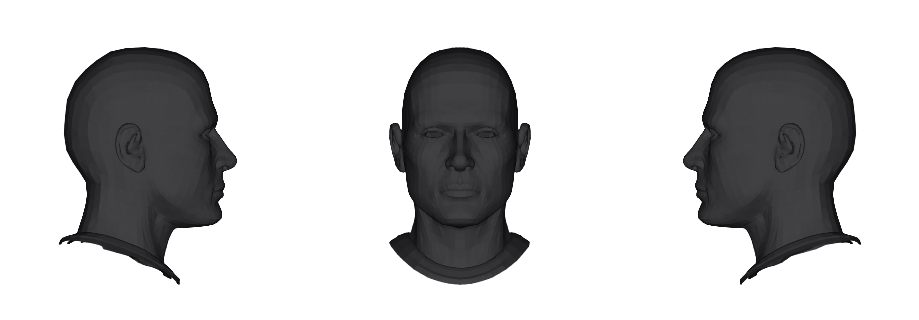

6


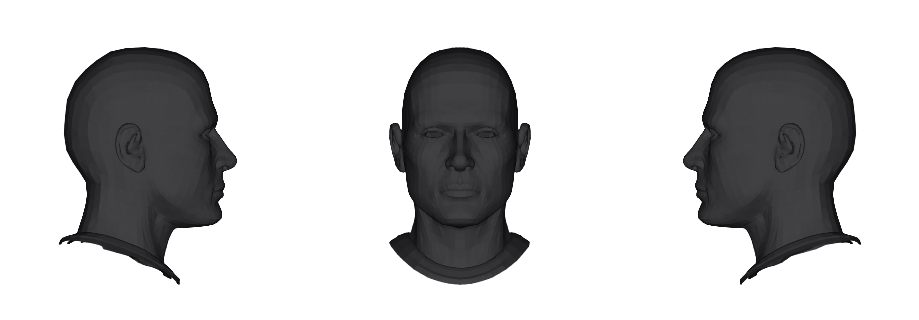

7


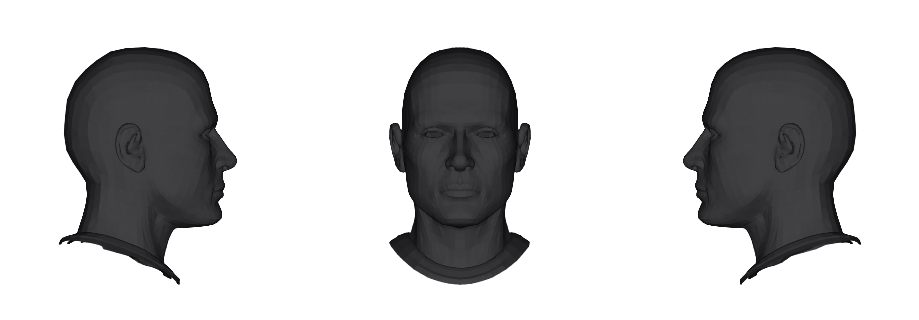

8


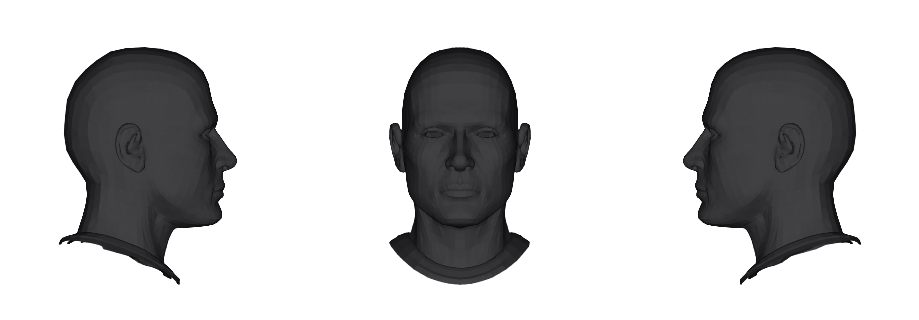

9


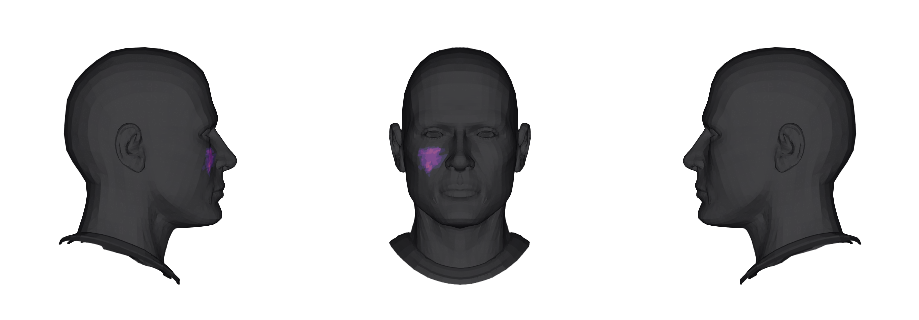

10


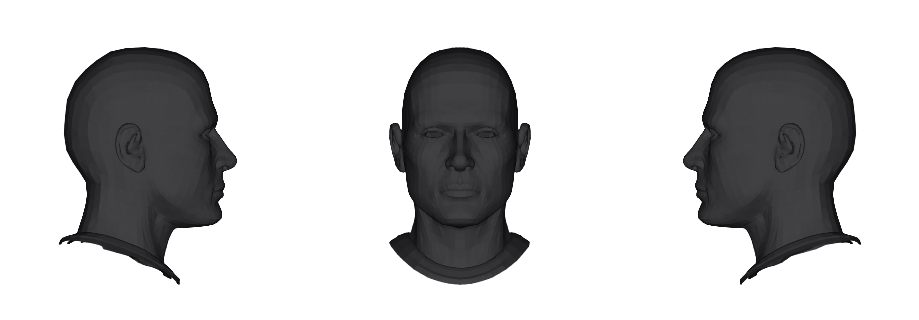

11


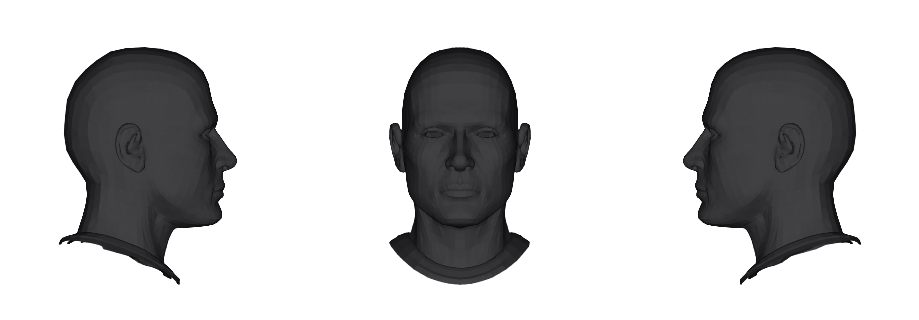

12


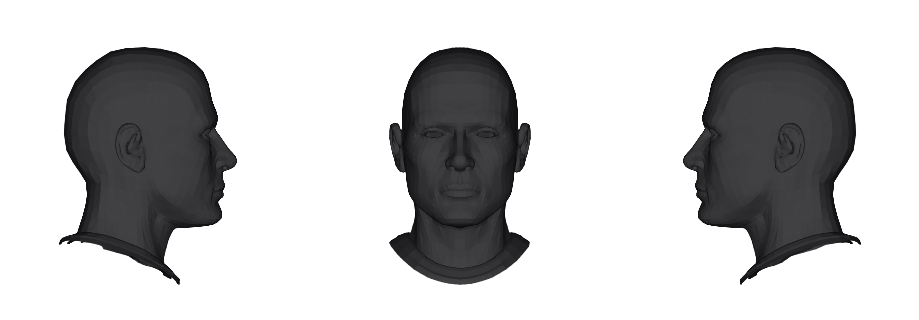

13


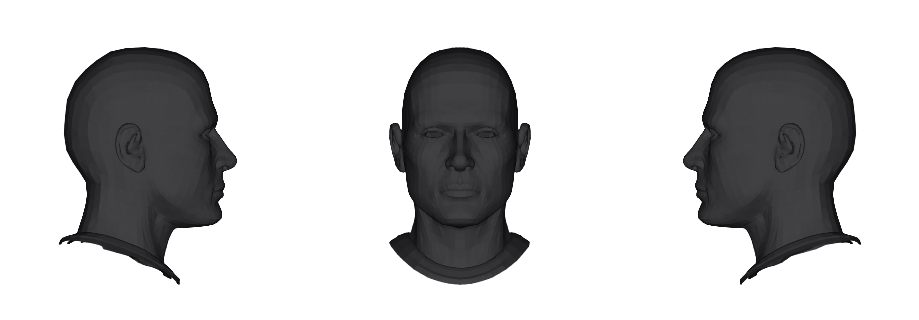

14


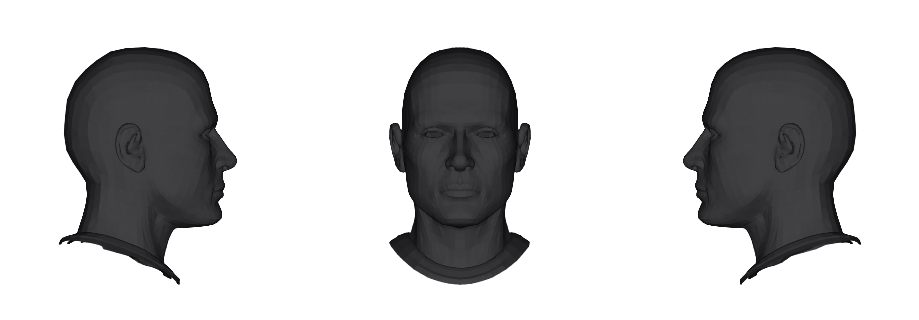

15


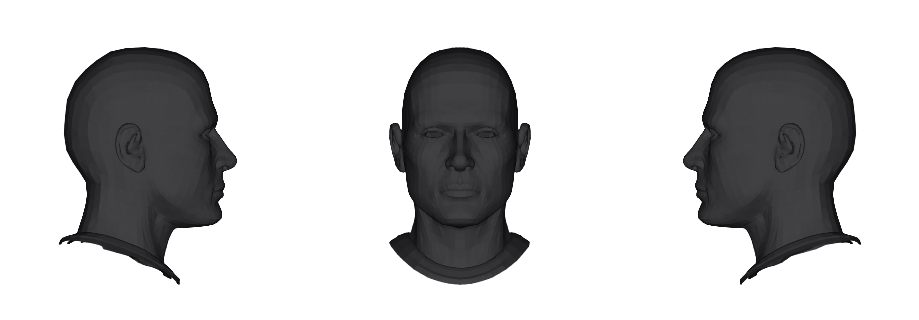

16


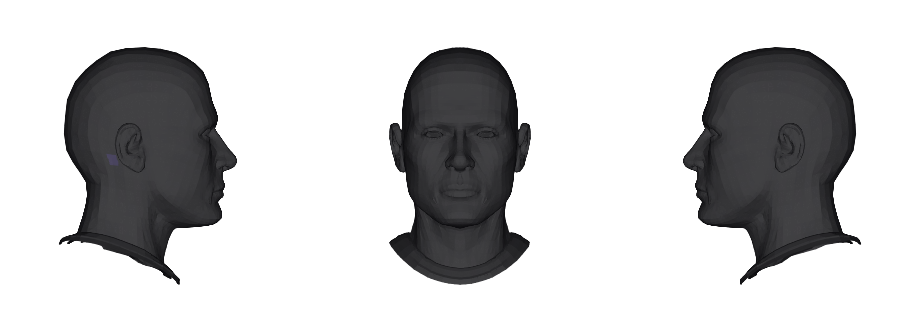

17


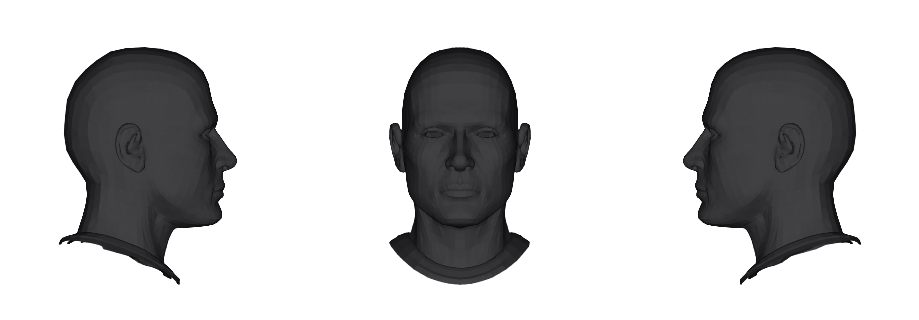

18


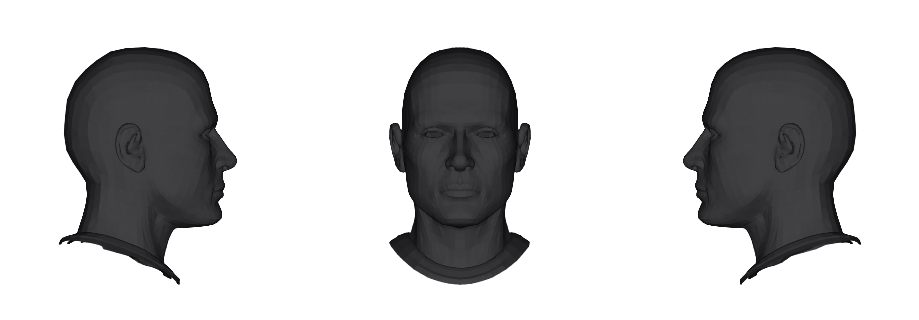

19


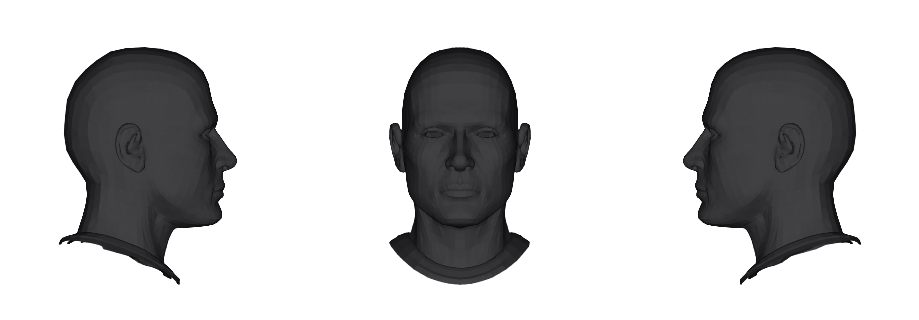

20


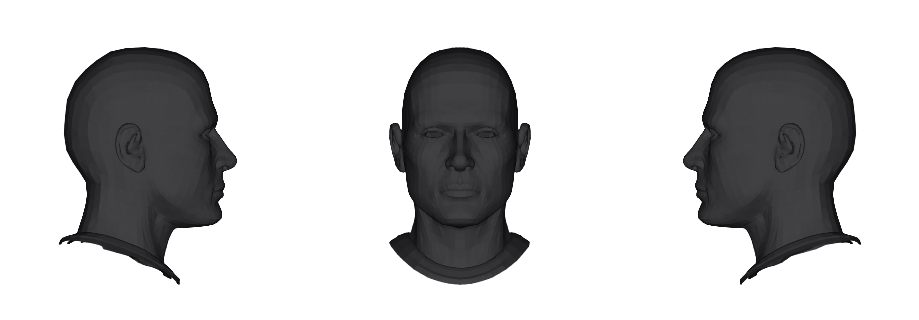

21


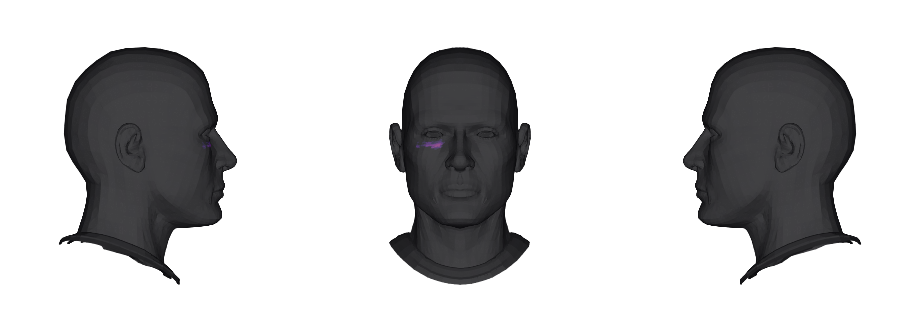

22


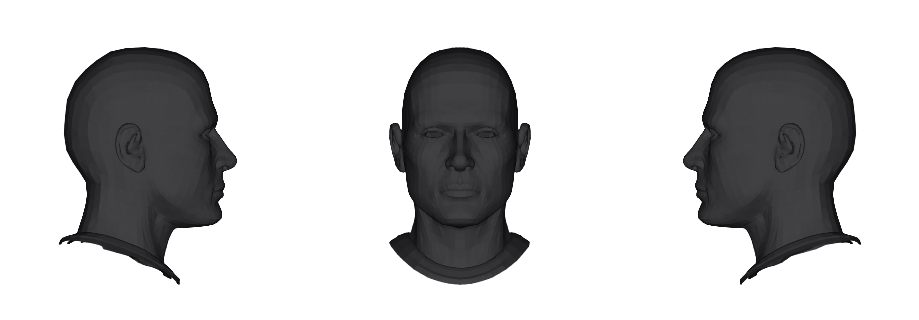

23


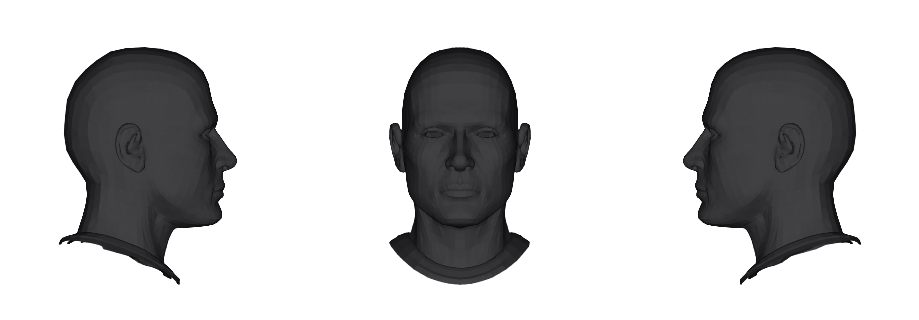

24


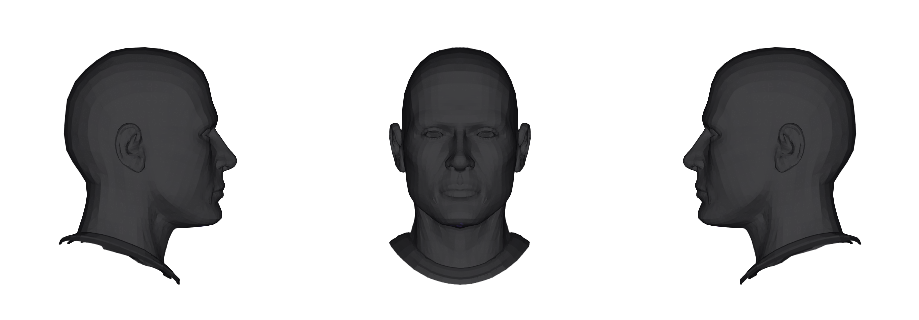

25


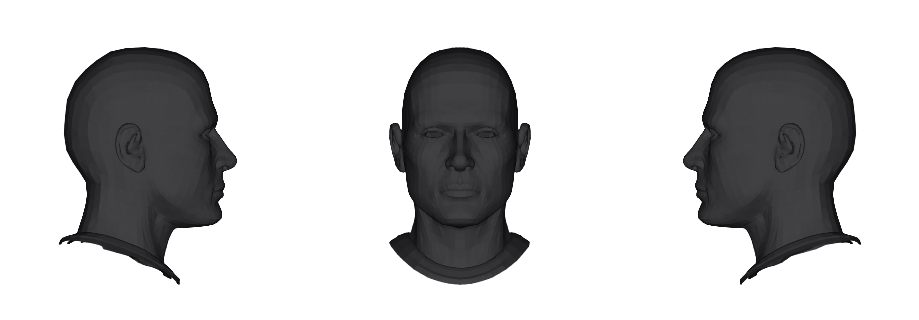

26


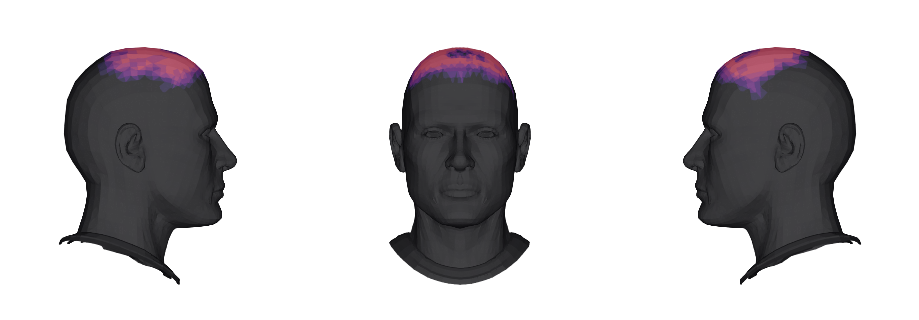

27


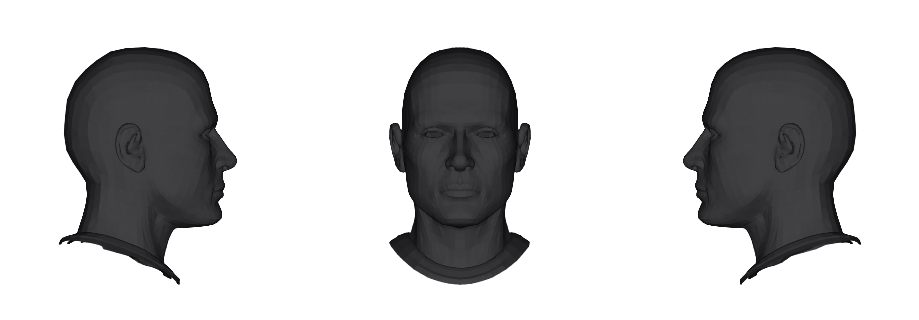

28


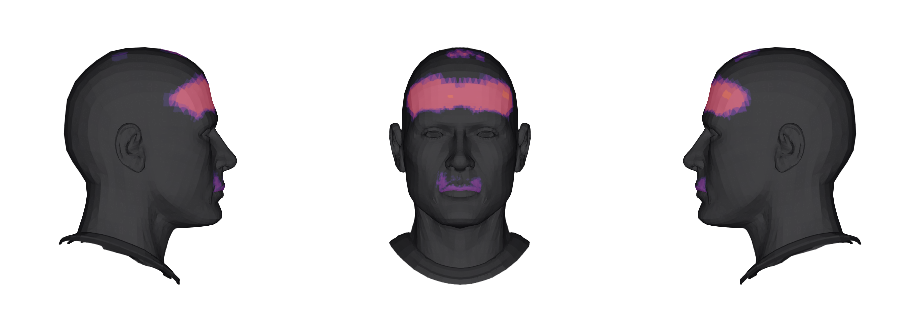

29


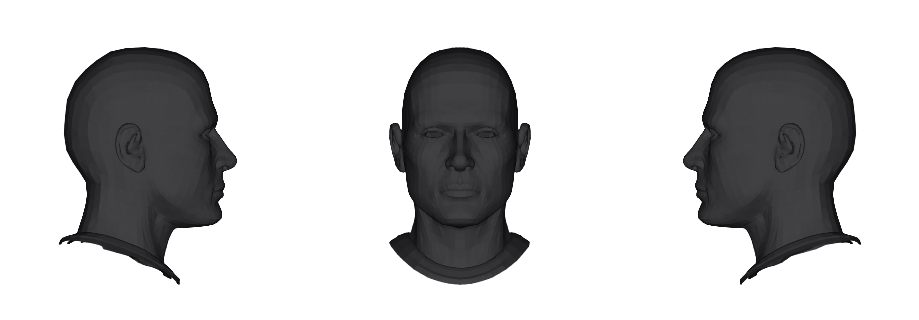

30


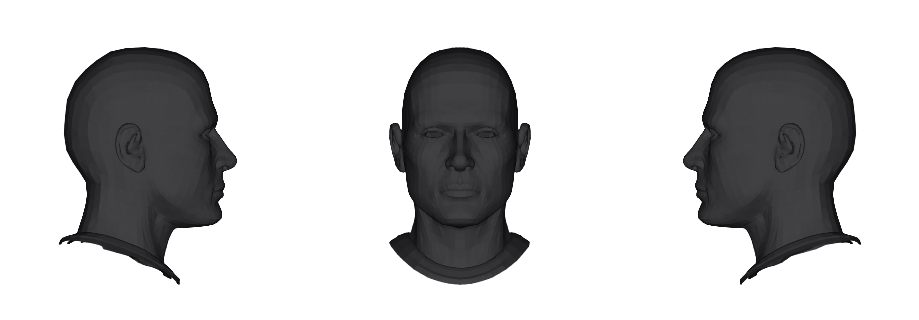

31


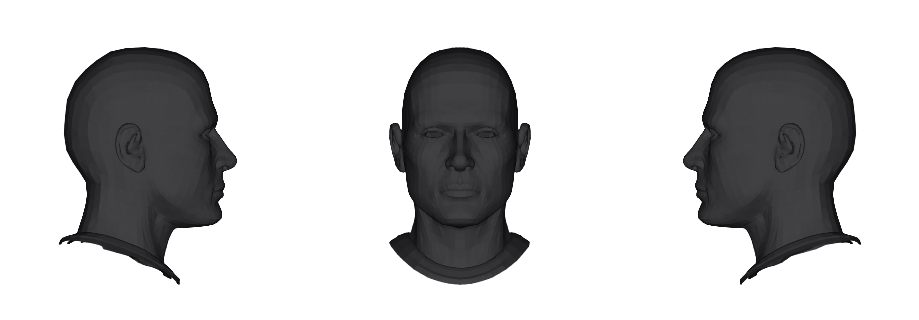

32


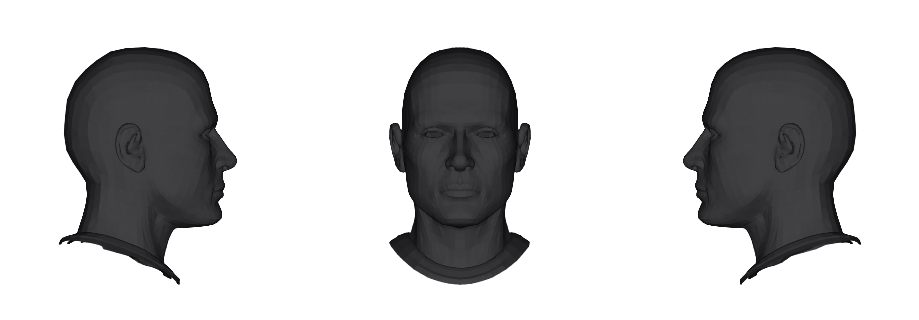

33


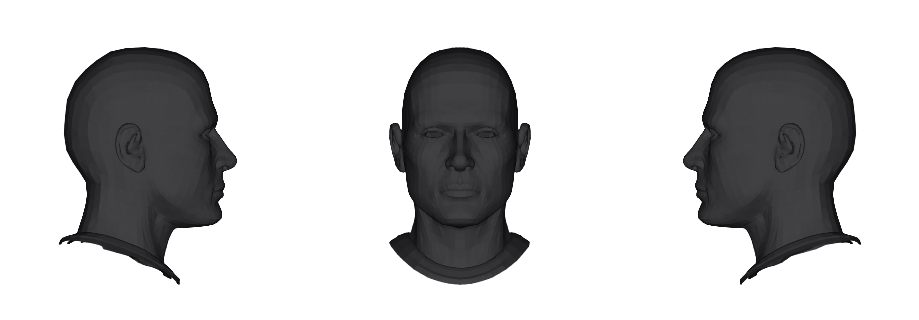

34


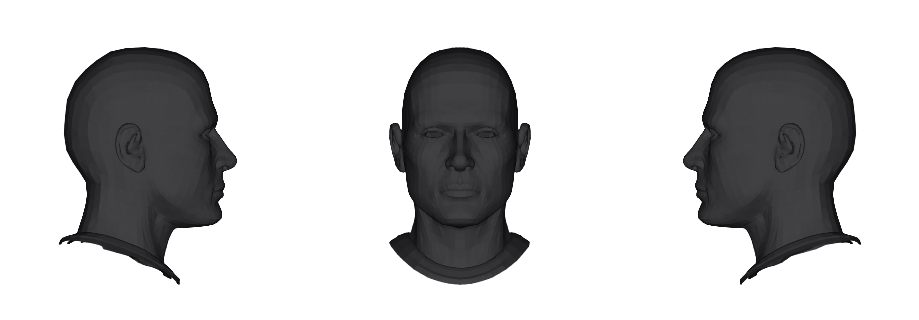

35


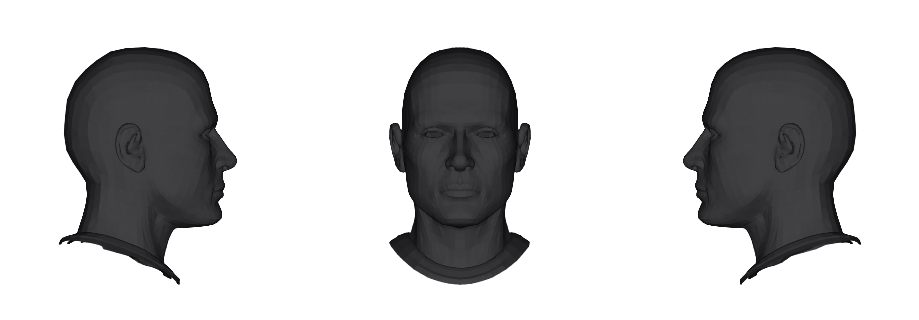

36


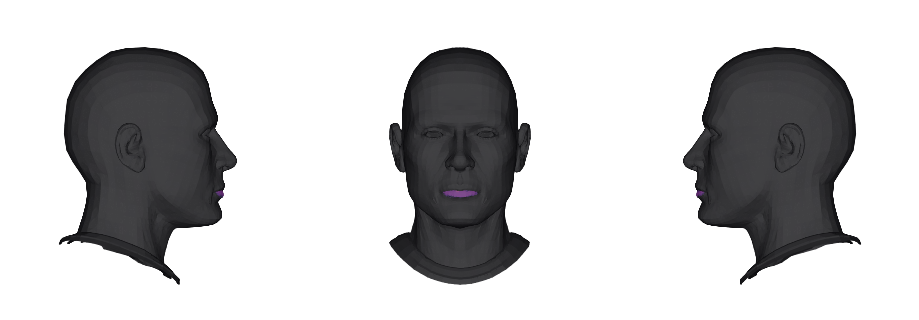

37


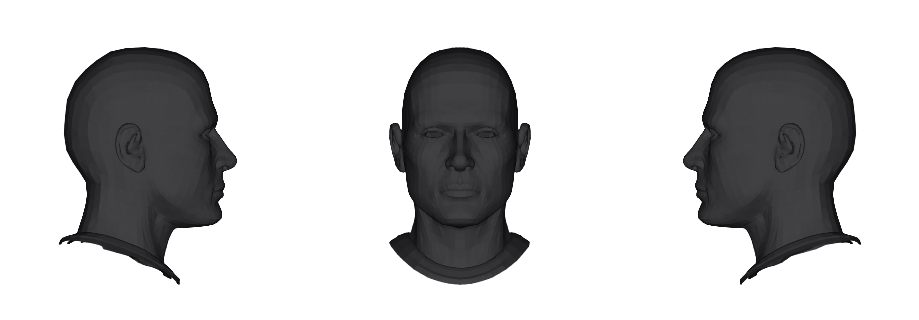

38


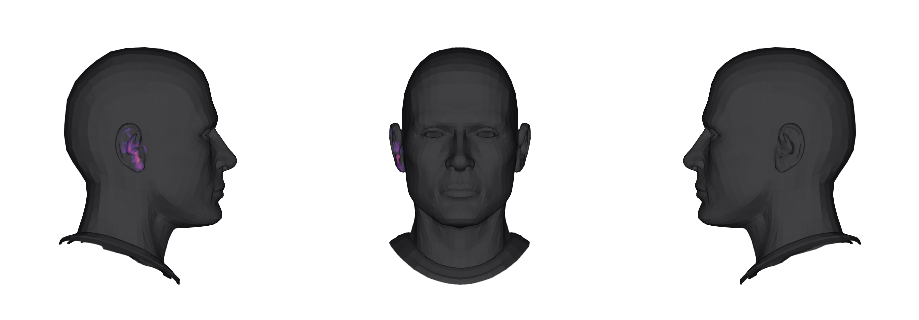

39


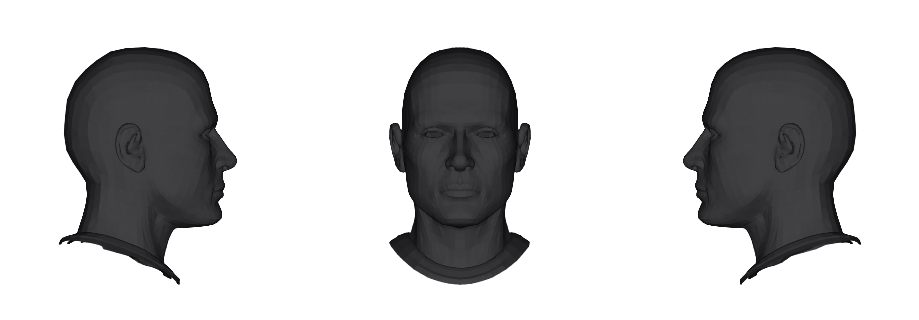

40


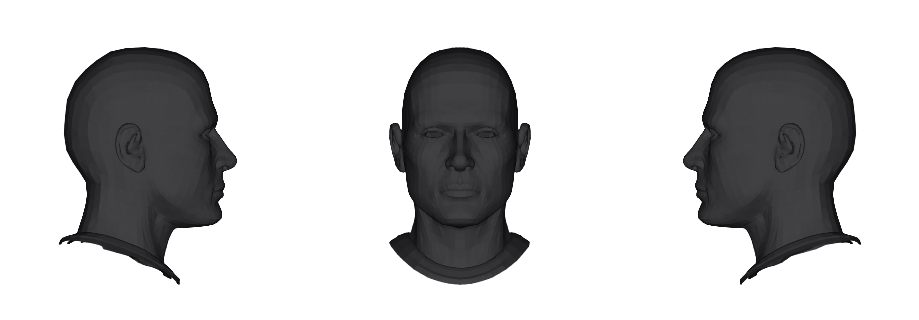

41


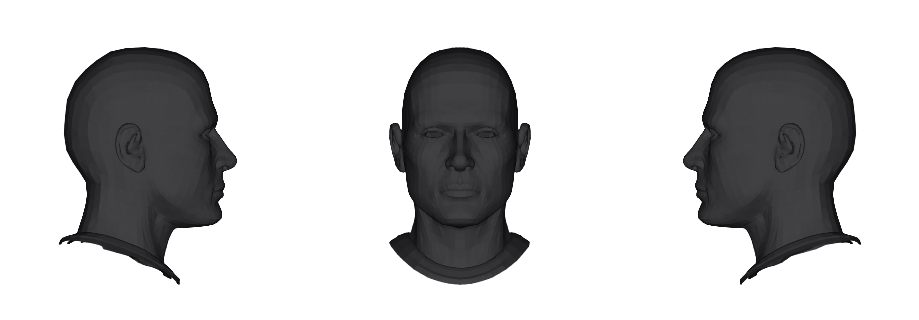

42


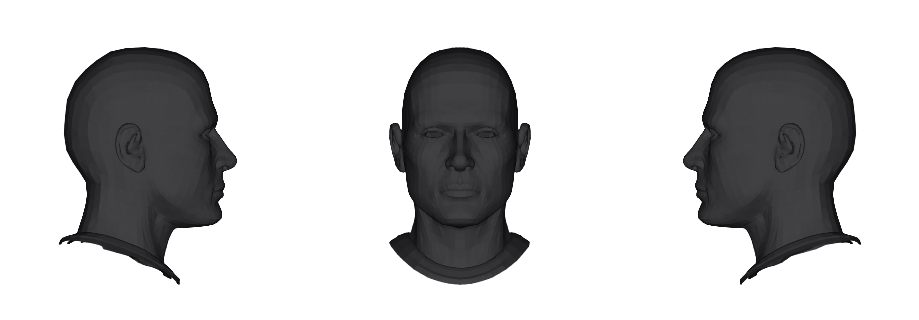

43


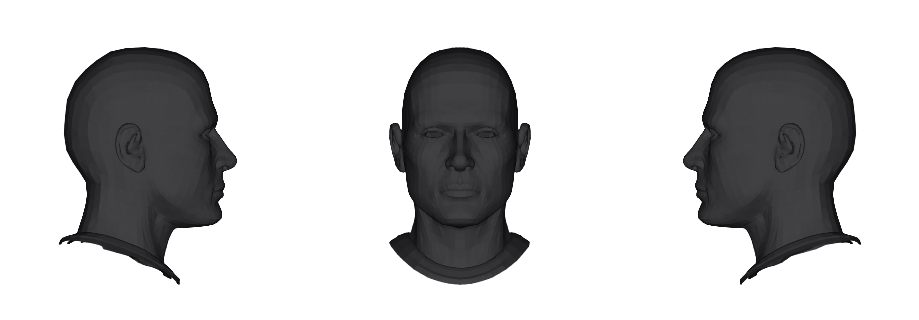

44


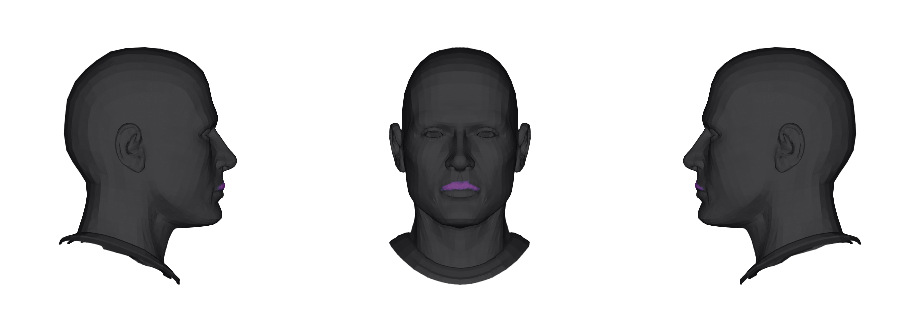

45


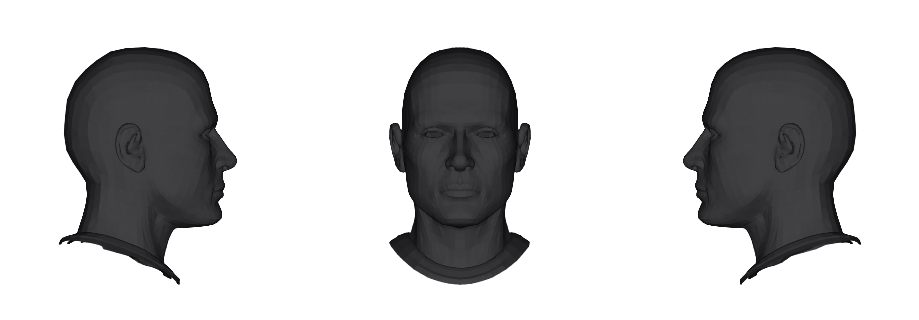

46


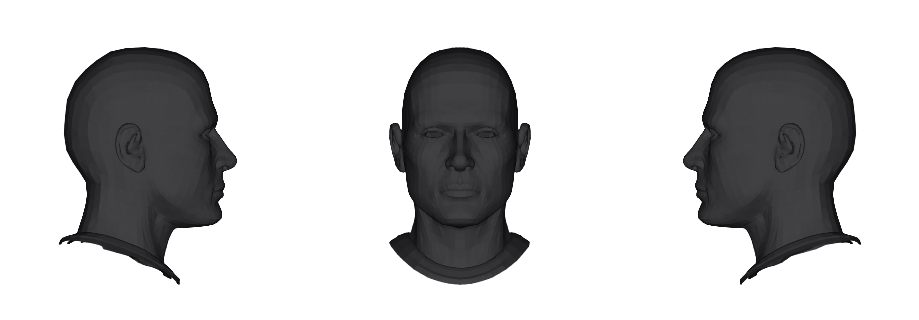

47


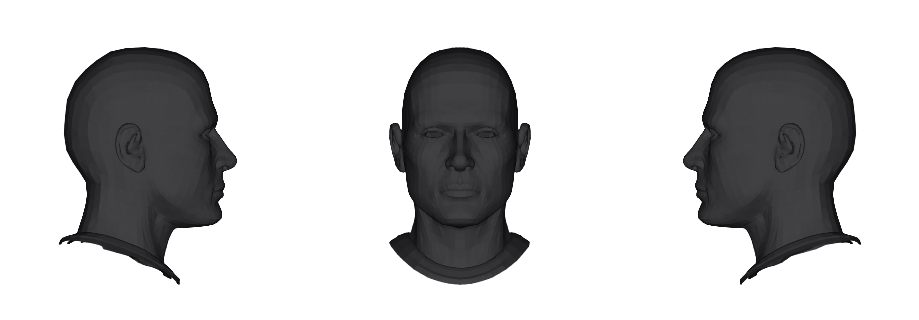

48


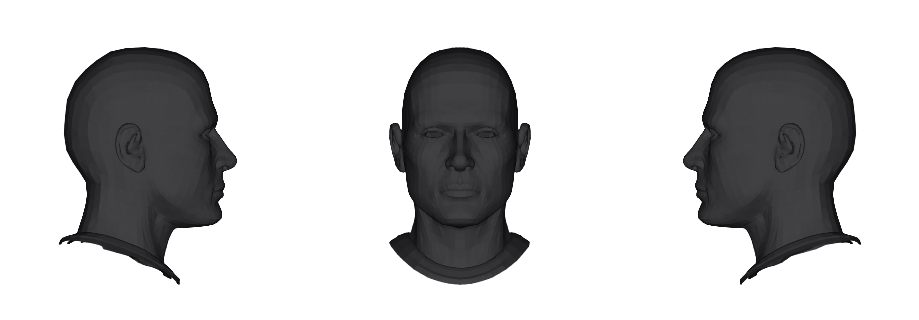

49


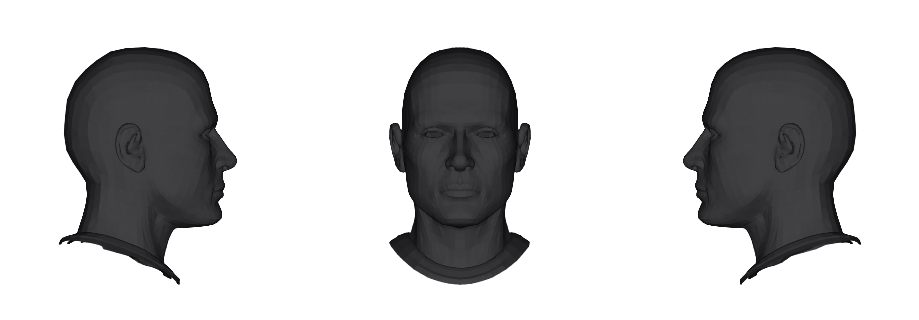

50


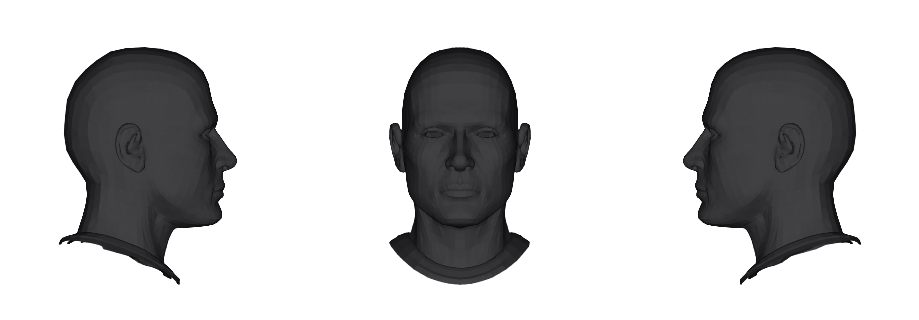

51


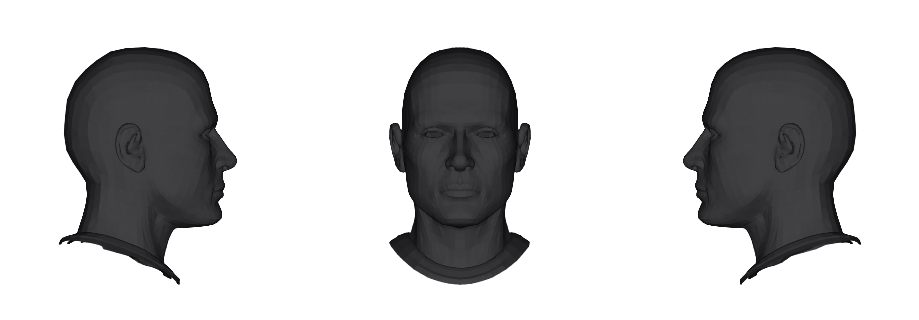

52


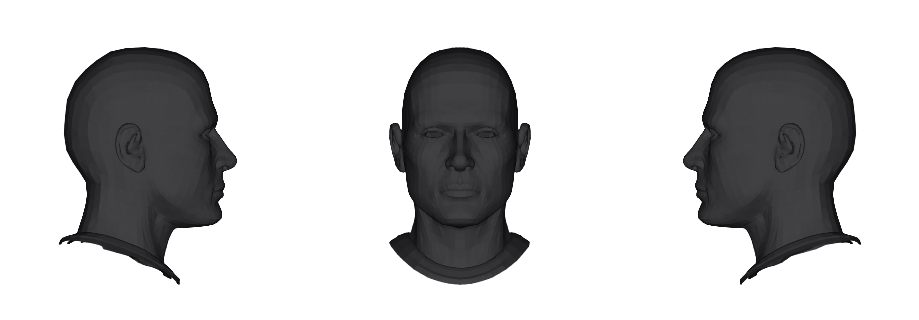

In [416]:
SIZE=3
for BS_N in range(53):
# BS_N = 36
    print(BS_N)

    # pred_sw5_bs = pred_sw5.detach().cpu()
    pred_sw5_bs = pred_sw5.detach().cpu()[..., :53]
    #pred_sw5_sm = torch.nn.functional.softmax(pred_sw5_bs, dim=-1)
    pred_sw5_sm = torch.nn.functional.softmax(abs(pred_sw5_bs), dim=-1)
    pred_sw5_1 = pred_sw5_sm[..., BS_N] * 3
    pred_sw5_1 = pred_sw5_1.type(torch.long)

    pred_sw5_1 = torch.eye(4)[pred_sw5_1]


    v_list=[ flame_tri.vertices * M_SCALE]
    f_list=[ flame_tri.faces ]

    c_list=[pred_sw5_1[0]]
    plot_image_array_seg(
        v_list *3, f_list *3, c_list *3,
        rot_list=[[0,90,0], [0,0,0], [0,-90,0]], 
        size=SIZE, bg_black=False, mode='shade', 
        logdir=f"_tmp/train", 
        c_map="inferno",
        name=f"test", save=False, blend = .7
    )

In [466]:

%load_ext autoreload
%autoreload 2
from utils.matplotlib_rnd import (
    render_mesh_diff,
    render_wo_audio,
    plot_image_array,
    plot_image_array_seg,
    plot_image_array_col,
    plot_image_array_grd
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


torch.Size([11248, 20])


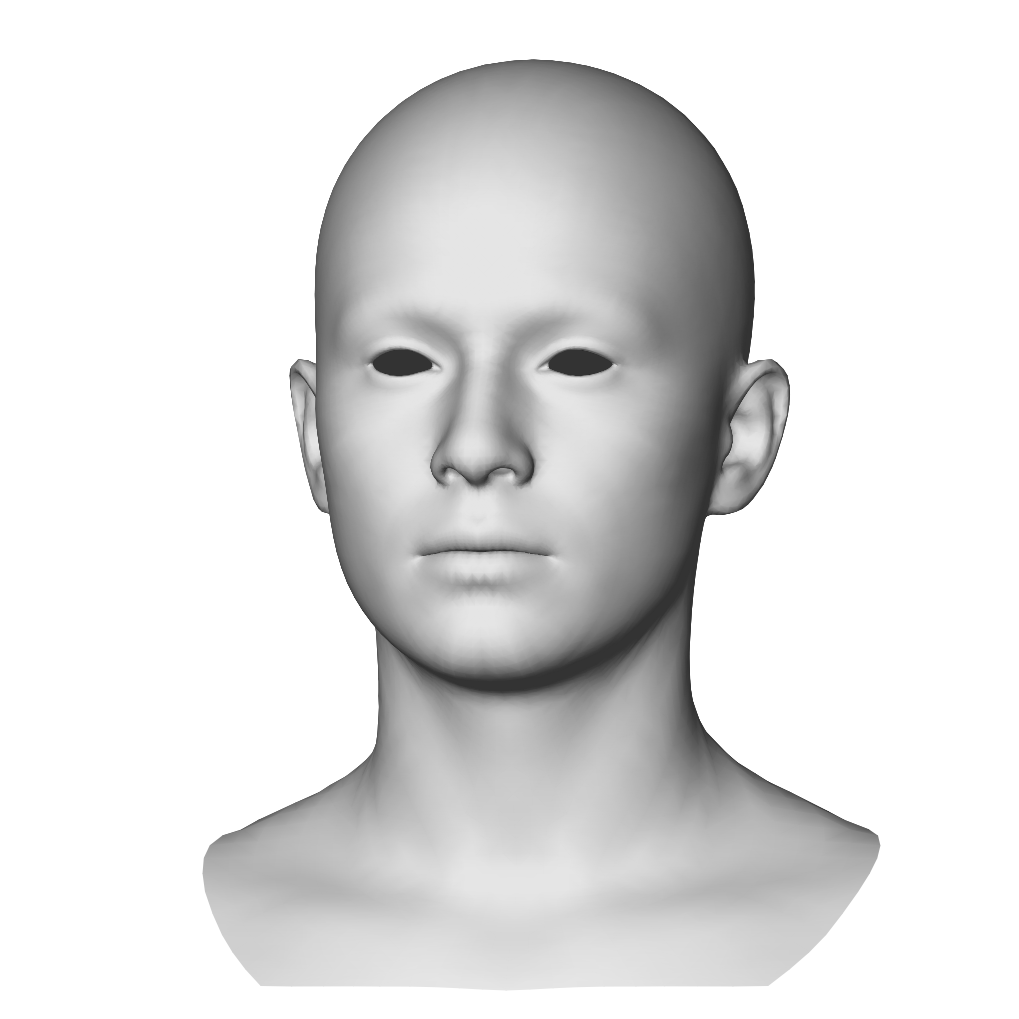

In [682]:

ict_vert_segment = torch.from_numpy(np.load('../utils/ict/ICT_segment_onehot.npy'))
print(ict_vert_segment.shape)
## ICT random expression
# BS_N = 29
# for BS_N in range(53):
for BS_N in range(1):
#     bs_coeff = np.eye(53)[BS_N]
#     vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
    vertices = ict_tri.vertices[None]
    #######################################################
    src_mesh = ict_tri
    tgt_mesh = flame_tri
    #######################################################

    M_SCALE = 0.55
    v_list=[ vertices[0] * M_SCALE]
    v_list=[ v+np.array([0,0.1,0]) for v in v_list]
    f_list=[ ict_tri.faces]
    SIZE=10

    plot_image_array_grd(
        v_list, f_list,
        rot_list=[[0,-10,0]]*len(v_list), 
        size=SIZE, 
        light_dir=np.array([0, 0.2, 1]),
        bg_black=False,
        logdir=f"tmp/ppt", 
        name=f"ICT-blendshape-{BS_N:03d}", 
        save=True
    )

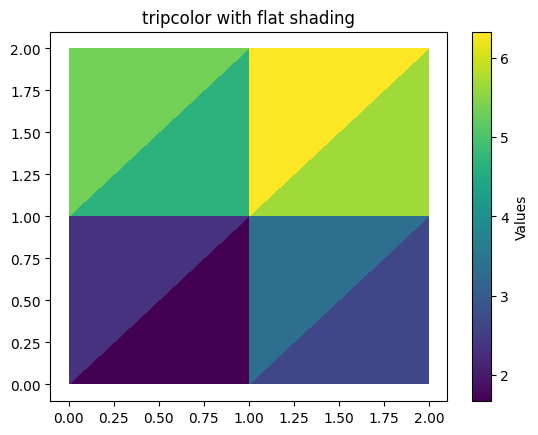

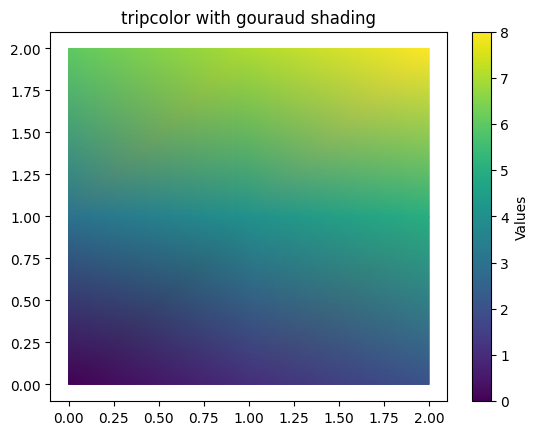

In [423]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# Sample data
x = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2])
y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])
z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
triangles = [[0, 1, 4], [1, 2, 5], [3, 4, 7], [4, 5, 8], [0, 3, 4], [1, 4, 5], [3, 6, 7], [4, 7, 8]]

# Create triangulation object
triang = tri.Triangulation(x, y, triangles)

# tripcolor plot with flat shading
plt.figure()
plt.tripcolor(triang, z, shading='flat')
plt.colorbar(label='Values')
plt.title('tripcolor with flat shading')

# tripcolor plot with gouraud shading
plt.figure()
plt.tripcolor(triang, z, shading='gouraud')
plt.colorbar(label='Values')
plt.title('tripcolor with gouraud shading')

plt.show()

In [63]:
print(pred_sw.shape, pred_seg.shape)

torch.Size([1, 2782, 128]) torch.Size([1, 2782, 20])


In [87]:
print(pred_sw.mean(1).min(-1), pred_sw.mean(1).max(-1))
print(pred_sw.std(1).min(-1), pred_sw.std(1).max(-1))

torch.return_types.min(
values=tensor([-4.5552], device='cuda:0', grad_fn=<MinBackward0>),
indices=tensor([59], device='cuda:0')) torch.return_types.max(
values=tensor([8.1293], device='cuda:0', grad_fn=<MaxBackward0>),
indices=tensor([115], device='cuda:0'))
torch.return_types.min(
values=tensor([0.7646], device='cuda:0', grad_fn=<MinBackward0>),
indices=tensor([20], device='cuda:0')) torch.return_types.max(
values=tensor([30.7725], device='cuda:0', grad_fn=<MaxBackward0>),
indices=tensor([115], device='cuda:0'))


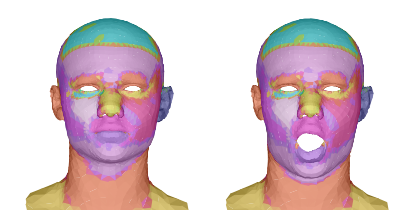

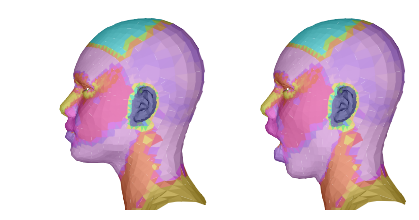

In [79]:

v_list=[ flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ flame_tri.faces, flame_tri.faces ]

c_list=[pred_sw.detach().cpu()[0], pred_sw.detach().cpu()[0]]

# c_map="rainbow"
# c_map="prism"
# c_map="nipy_spectral"
c_map="gist_ncar"
    
plot_image_array_seg(
    v_list, f_list, c_list, 
    rot_list=[[0,0,0]] * 2, 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", c_map=c_map,
    name=f"test", save=False
)

plot_image_array_seg(
    v_list, f_list, c_list, 
    rot_list=[[0,-90,0]] * 2, 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", c_map=c_map,
    name=f"test", save=False
)

In [6]:
print(pred_seg.shape)
import pickle
import torch.nn.functional as F

with open("MF_seg.pkl","wb") as f:
    pred_seg = pred_seg.detach().cpu()
    pred_seg = F.softmax(pred_seg, dim=-1)
    print(pred_seg.shape)
    pickle.dump(pred_seg.detach().cpu().numpy(), f)

torch.Size([1, 5223, 20])
torch.Size([1, 5223, 20])


In [54]:
pred_outputs2, pred_seg = trainer.model.inference(
    gt_vertices=pred_outputs, 
    src_mesh=tgt_mesh, 
    tgt_mesh=src_mesh,
    return_seg=True,
)

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


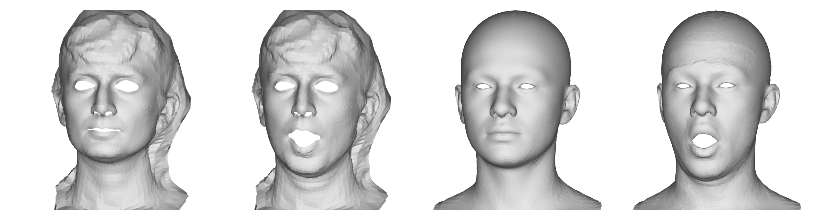

 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


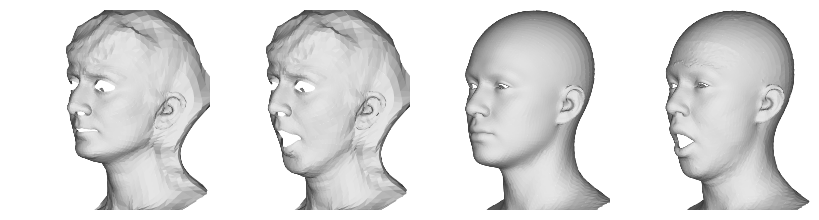

In [55]:
v_list=[ flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE, ict_tri.vertices * M_SCALE, pred_outputs2.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ flame_tri.faces, flame_tri.faces, ict_tri.faces, ict_tri.faces]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)
print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-50,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)


In [2]:
# from tqdm import tqdm
# flame_tri = trimesh.load('/data/sihun/arkit_CSH/arkit_frame_000000.obj', process=False, maintain_order=True)
# flame_tri.vertices = flame_tri.vertices[:ict_tri.vertices.shape[0]] *0.1
# flame_tri.faces = ict_tri.faces
    
# gt_frames = []
# for objfile in tqdm(sorted(glob.glob('/data/sihun/arkit_CSH/*.obj'))):
#     flame_tri = trimesh.load(objfile, process=False, maintain_order=True)
#     gt_frames.append(flame_tri.vertices[:ict_tri.vertices.shape[0]] *0.1)
# gt_frames=np.array(gt_frames)
# gt_frames=torch.tensor(gt_frames)
# print(gt_frames.shape)
# # torch.save(gt_frames, "gt_frames.pth")

In [17]:
import sys
import pickle
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']

from utils.matplotlib_rnd import render_wo_audio
from IPython.display import Video

import torch
import trimesh
from utils import ICT_face_model
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

gt_frames = torch.load("gt_frames.pth") - torch.tensor([0.0, 0.0, 0.5])

/source/sihun/NFS/utils/matplotlib_rnd.py:1510: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
rendering: 100%|██████████| 1207/1207 [06:40<00:00,  3.02it/s]

saved as: tmp/arkit_CSH_shade.mp4


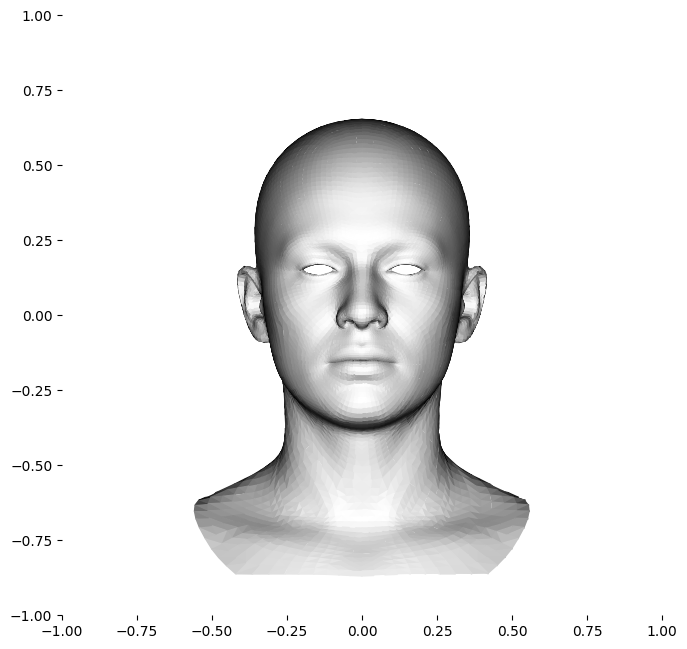

In [11]:


render_wo_audio(Vs=gt_frames[:10]*0.45, F=ict_tri.faces, size=6, mode='shade', savename="arkit_CSH_shade_")

In [12]:
Video("tmp/arkit_CSH_shade.mp4")

In [20]:
gt_frames.shape 

torch.Size([1207, 11248, 3])

In [112]:
tgt_mesh.vertices.shape

(15941, 3)

In [207]:
# for gt_frame in gt_frames:
pred_outs, (vert_feat, pred_exp, pred_id, pred_seg, _, tgt_v, tgt_f, tgt_op) = trainer.model.inference(
    gt_vertices=gt_frames, 
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh,
    use_filter=True,
    return_all=True,
)

decoding...: 100%|██████████| 1207/1207 [00:01<00:00, 901.97it/s]


In [208]:
NAME="arkit_CSH_shade-mary_test"
with open(f"tmp/arkit/{NAME}.pkl", "wb") as f:
    asd = {"pred_outs":pred_outs,"pred_seg":pred_seg}
    pickle.dump(asd, f)

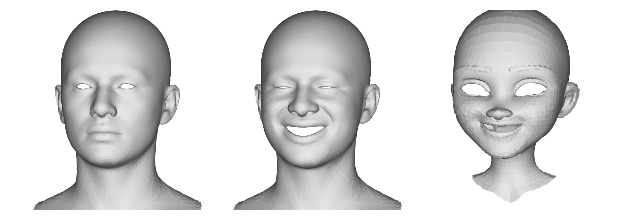

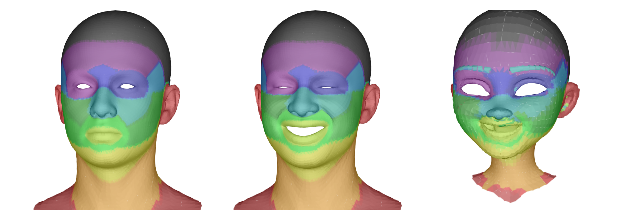

In [210]:
M_SCALE = 0.68
FRAME=200
v_list=[ ict_tri.vertices*M_SCALE, gt_frames[FRAME] * M_SCALE, pred_outs[FRAME].detach().cpu() * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, tgt_mesh.faces, ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

c_list=[ict_vert_segment, ict_vert_segment, pred_seg.detach().cpu()[0] ]
plot_image_array_seg(
    v_list, f_list, c_list, 
    rot_list=[[0,-10,0]] * len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

rendering: 100%|██████████| 1207/1207 [02:23<00:00,  8.39it/s]


saved as: tmp/arkit_CSH_shade-bonnie_test.mp4


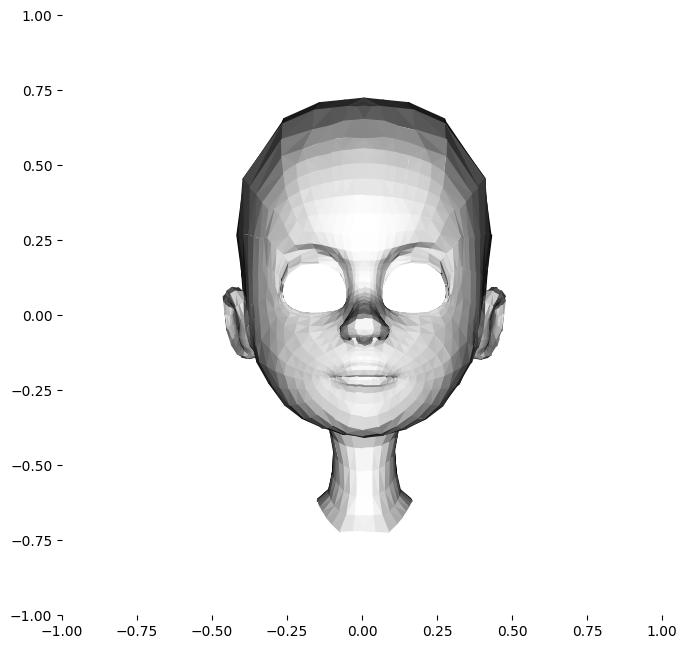

In [142]:
render_wo_audio(Vs=pred_outs.detach().cpu()*0.45, F=tgt_mesh.faces, size=6, mode='shade', savename=NAME)

mary
1.534326159664362
-1.3655930003356382
[ 2.93940588e-17 -1.36259327e-15  2.50000000e-01]


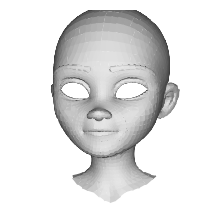

In [15]:
import random
import trimesh

def set_seed(num):
    # set seed
    torch.manual_seed(num)
    torch.cuda.manual_seed(num)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(num)
    random.seed(num)
    
set_seed(0)
    
ict_basedir='/data/sihun/ICT-audio2face/split_set'
ict_syn_basedir='/data/sihun/ICT-audio2face/synth_set'
voca_basedir="/data/sihun/VOCASET/original_set"
biwi_basedir="/data/sihun/BIWI"
mf_basedir="/data/sihun/multiface/audio2face"

biwi_align_mat = np.load(f'{abs_path}/utils/biwi/align.npy')
voca_align_mat = np.load(f'{abs_path}/utils/voca/align.npy')
# voca_std = np.load('./utils/voca/standardization.npy', allow_pickle=True).item()

def mesh_alignment(vertices, mean=None, mesh_data="voca", return_mean=False):
    if mesh_data == "biwi":
        mat = biwi_align_mat

        if mean is None:
            mean = vertices.mean(0)
        vertices = vertices - mean
    elif mesh_data == "voca":
        mat = voca_align_mat

    vertices = np.c_[vertices, np.ones([*vertices.shape[:-1], 1])]
    vertices = vertices @ mat.T
    vertices = vertices[..., :3]
    if return_mean:
        return vertices, mean
    return vertices

def xrot3x3(theta):
    t = np.pi * theta / 180
    c, s = np.cos(t), np.sin(t)
    return  np.array([[ 1, 0, 0],
                      [ 0, c,-s],
                      [ 0, s, c]], dtype=float)


smesh_name = 'mary'

## malchom
if smesh_name == 'malchom':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices - s_mesh.vertices.mean(0)
    s_mesh.vertices = s_mesh.vertices * 0.09
    s_mesh.vertices = s_mesh.vertices + np.array([[0, 0.08, 0.3]])
    
elif smesh_name == 'mary':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices - s_mesh.vertices.mean(0)
    s_mesh.vertices = s_mesh.vertices * 0.17
    s_mesh.vertices = s_mesh.vertices + np.array([[0, 0.0, 0.25]])
    
elif smesh_name == 'bonnie':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}-head-bald-align.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices + np.array([[0, -0.02, 0.25]])
    
elif smesh_name == 'morphy':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}-bald-align.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices + np.array([[0, 0, -0.25]])

elif smesh_name=='girl':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices - s_mesh.vertices.mean(0)
    s_mesh.vertices = s_mesh.vertices * 0.087
    s_mesh.vertices = s_mesh.vertices @ xrot3x3(-1).T
#     s_mesh.vertices = s_mesh.vertices + np.array([[0, 0.2, -0.25]])
    s_mesh.vertices = s_mesh.vertices + np.array([[0, 0.05, -0.12]])

elif smesh_name=='piers':
    s_mesh = trimesh.load(f'{abs_path}/test-mesh/{smesh_name}.obj',process=False, maintain_order=True)
    s_mesh.vertices = s_mesh.vertices - s_mesh.vertices.mean(0)
    s_mesh.vertices = s_mesh.vertices * 0.2
    s_mesh.vertices = s_mesh.vertices + np.array([[0, 0.15, -0.11]])

print(smesh_name)
print(s_mesh.vertices.max())
print(s_mesh.vertices.min())
print(s_mesh.vertices.mean(0))
torch.cuda.empty_cache()


M_SCALE = 0.68
v_list=[ s_mesh.vertices * M_SCALE ]
f_list=[ s_mesh.faces]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [45]:
# _=s_mesh.export(f'{abs_path}/test-mesh/{smesh_name}-align.obj')

In [1]:
import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']
from utils.matplotlib_rnd import plot_image_array

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [1]:
import torch
import pickle
import numpy as np

In [3]:
import trimesh
s_mesh = trimesh.load('/data/sihun/char_mesh/result/mary.obj',process=False, maintain_order=True)
s_mesh.vertices = s_mesh.vertices - s_mesh.vertices.mean(0)
s_mesh.vertices = s_mesh.vertices * 0.17 + np.array([[0, 0.0, 0.25]])
print(s_mesh.vertices.shape)
print(s_mesh.faces.shape)

(5065, 3)
(10004, 3)


In [4]:
mean_ = torch.load('/data/sihun/char_mesh/result/mary/mean.pth')
with open('/data/sihun/char_mesh/result/mary/pca.pkl', 'rb')as f:
    pca_ = pickle.load(f)
weight_ = torch.load('/data/sihun/char_mesh/result/mary/weight.pth')

In [5]:
print(weight_.min(0)[0])
print(weight_.max(0)[0])

tensor([-11.0564,  -7.9815,  -9.0081,  -8.1547,  -4.3829,  -1.4876,  -6.2374,
         -2.4031,  -2.2223,  -1.3837,  -1.0598,  -0.8263,  -1.0252,  -0.7901,
         -1.2358,  -0.8891,  -0.6610,  -0.4025,  -0.5527,  -0.6370])
tensor([34.0104, 12.7694, 11.6051,  9.3249,  7.1121,  4.1460,  6.5272,  2.4115,
         3.1491,  1.8350,  1.1535,  1.1184,  1.2577,  1.0256,  1.5983,  1.5497,
         0.8389,  0.5302,  0.6024,  0.6914])


In [6]:
print(pca_.mean_.shape)
print(weight_.shape)

(15195,)
torch.Size([18810, 20])


In [7]:
pca_V = pca_.mean_ + np.dot (weight_[100], pca_.components_)
pca_V = pca_V.reshape(-1, 3) 
pca_V = (pca_V- pca_V.mean(0))* 0.17 + np.array([[0, 0.0, 0.25]])
print(pca_V.shape)

(5065, 3)


In [63]:
M_SCALE = 0.68
v_list=[ s_mesh.vertices * M_SCALE, pca_V * M_SCALE]
f_list=[ s_mesh.faces, s_mesh.faces]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

NameError: name 'pca_V' is not defined

In [2]:
from utils.remesh_utils import ICT_face_model
import os
import glob
import trimesh

ict = ICT_face_model()
v_num, faces = ict.get_random_v_and_f(select=2)

new_path = '/data/sihun/ICT-audio2face/precompute-synth-narrow_face'
os.makedirs(new_path, exist_ok=True)

data_path = '/data/sihun/ICT-audio2face/precompute-synth-fullhead'
mesh_filelist = glob.glob(data_path+'/*.obj')
for m_files in mesh_filelist:
    #print(m_files)
    t_mesh = trimesh.load(m_files)
    t_mesh.vertices = t_mesh.vertices[:v_num]
    t_mesh.faces = faces
    _=t_mesh.export(os.path.join(new_path, m_files.split('/')[-1]))

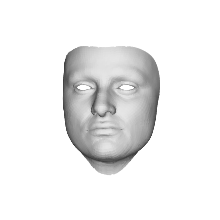

In [3]:
M_SCALE = 0.68
v_list=[ t_mesh.vertices * M_SCALE]
f_list=[ t_mesh.faces]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [28]:
from utils.matplotlib_rnd import render_wo_audio
from IPython.display import Video

In [58]:
asdasd  = sorted(os.listdir('/data/sihun/multiface_align/ROM/train/vertices_npy/m--20180105--0000--002539136--GHS'))
print(asdasd)

['E001_Neutral_Eyes_Open', 'E002_Swallow', 'E003_Neutral_Eyes_Closed', 'E004_Relaxed_Mouth_Open', 'E005_Eyes_Wide_Open', 'E006_Jaw_Drop_Brows_Up', 'E007_Neck_Stretch_Brows_Up', 'E008_Smile_Mouth_Closed', 'E009_Smile_Mouth_Open', 'E010_Smile_Stretched', 'E011_Jaw_Open_Sharp_Corner_Lip_Stretch', 'E012_Jaw_Open_Huge_Smile', 'E013_Open_Lips_Mouth_Stretch_Nose_Wrinkled', 'E014_Open_Mouth_Stretch_Nose_Wrinkled', 'E015_Jaw_Open_Upper_Lip_Raised', 'E016_Raise_Upper_Lip_Scrunch_Nose', 'E017_Jaw_Open_Mouth_Corners_Down_Nose_Wrinkled', 'E018_Raise_Cheeks', 'E019_Frown', 'E020_Lower_Eyebrows', 'E021_Pressed_Lips_Brows_Down', 'E022_Raise_Inner_Eyebrows', 'E023_Hide_Lips_Look_Up', 'E024_Kiss_Lips_Look_Down', 'E025_Shh', 'E026_Oooo', 'E027_Scrunch_Face_Squeeze_Eyes', 'E028_Scream_Eyebrows_Up', 'E029_Show_All_Teeth', 'E030_Open_Mouth_Wide_Tongue_Up_And_Back', 'E031_Jaw_Open_Lips_Together', 'E032_Jaw_Open_Pull_Lips_In', 'E033_Jaw_Clench', 'E034_Jaw_Open_Lips_Pushed_Out', 'E035_Lips_Together_Pushed_Forw

In [66]:
asd
# data/sihun/multiface_align/precomputes_prev/m--20171024--0000--002757580--GHS_dfn_info.pkl
# data/sihun/multiface_align/precomputes/m--20171024--0000--002757580--GHS_dfn_info.pkl
# data/sihun/multiface_align/precomputes/m--20171024--0000--002757580--GHS_mesh_dfn_info.pkl

'E074_Blink'

KeyboardInterrupt: 

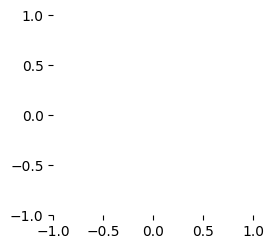

In [74]:
import pickle
biwi_templates = pickle.load(open('/data/sihun/BIWI_align_deci/templates_align_deci.pkl', 'rb'), encoding='latin1')
    
#s_mesh = trimesh.Trimesh(vertices=biwi_templates['F3'], faces=biwi_templates['face'], process=False, maintain_order=True)

s_mesh = trimesh.load('/data/sihun/multiface_align/obj/m--20180105--0000--002539136--GHS_mesh.obj', process=False, maintain_order=True)
# # m--20180105--0000--002539136--GHS_mesh
# M_SCALE = 0.68
# v_list=[ s_mesh.vertices * M_SCALE]
# f_list=[ s_mesh.faces]
# SIZE=2

# plot_image_array(
#     v_list, f_list,
#     rot_list=[[0,-10,0]]*len(v_list), 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"_tmp/train", 
#     name=f"test", save=False
# )

select = 3
for asd in asdasd:
    #vs = []
    os.makedirs('_tmp/train', exist_ok=True)
    for npy in sorted(glob.glob(f'/data/sihun/multiface_align/ROM/train/vertices_npy/m--20180105--0000--002539136--GHS/{asd}/*.npy')):
        plot_image_array(
            [np.load(npy)], [s_mesh.faces],
            rot_list=[[0,-10,0]]*len(v_list), 
            size=SIZE, bg_black=False, mode='shade', 
            logdir=f"_tmp/train", 
            name=asd+npy.split('/')[-1], 
            save=True
        )
#         vs.append(np.load(npy))
#     f = [s_mesh.faces]
#     render_wo_audio(Vs=vs, F=s_mesh.faces, savename = f'{asd}')
# vs =np.array(vs)
# f = np.array(f)
# print(vs.shape, f.shape)

In [62]:
print(asd[select])
Video('tmp/temp.mp4')

0


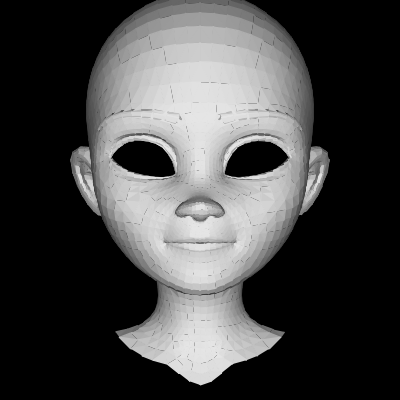

interactive(children=(IntSlider(value=0, description='Frame:', max=18809), IntSlider(value=0, description='Ang…

In [11]:

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


def update_frame(frame, angle=0):
    #plt.close()
    pca_V = pca_.mean_ + np.dot (weight_[frame], pca_.components_)
    pca_V = pca_V.reshape(-1, 3) 
    pca_V = (pca_V- pca_V.mean(0))* 0.17 + np.array([[0, 0.0, 0.25]])
    
    
    v_list = [
        (pca_V * M_SCALE), 
    ]
    f_list = [s_mesh.faces]*len(v_list)
    plot_image_array(
        v_list, 
        f_list, 
        rot_list=[[0,angle,0]]*len(v_list),
        mode='shade',
        size=4
        )

# 슬라이더 위젯 생성
slider     = widgets.IntSlider(value=0, min=0, max=weight_.shape[0]-1, step=1, description='Frame:')
angle_     = widgets.IntSlider(value=0, min=0, max=180, step=1, description='Angle:')

# 슬라이더 위젯과 update_frame 함수 연결

interactive_plot = widgets.interactive(update_frame, frame=slider, angle=angle_)
display(interactive_plot)
